Title: Calculate_var_means.ipynb

Purpose: 

Author: Onno Nennecke on 14.05.2025 Modified: 14.05.2025

Input data: 

    - This file lies here: 

Output data:

    - This file lies here: 

### Load libraries and functions

In [2]:
# Importing libraries
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import glob
import time
import re
import cftime

from matplotlib.ticker import MultipleLocator
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER

# Importing functions
import Functions.grid_func as grid_func
import Functions.winter_date_func as winter_date_func


/home/onennecke/.conda/envs/env_ma_on/lib/python3.12/site-packages/esmpy/interface/loadESMF.py:94: VersionWarning: ESMF installation version 8.8.0, ESMPy version 8.8.0b0
  warnings.warn("ESMF installation version {}, ESMPy version {}".format(


### Load datasets

In [2]:
# Load installed capacity data
grid_offshore = xr.open_dataset('/climca/people/onennecke/Wind_Solar_MaStR/processed_data/wind_offshore_ic.nc')
grid_offshore = grid_offshore['wind_off_cap']
mask_offshore = xr.where(np.isfinite(grid_offshore), 1, 0)
grid_onshore = xr.open_dataset('/climca/people/onennecke/Wind_Solar_MaStR/processed_data/wind_onshore_ic.nc')
grid_onshore = grid_onshore['wind_on_cap']
mask_onshore = xr.where(np.isfinite(grid_onshore), 1, 0)
grid_solar = xr.open_dataset('/climca/people/onennecke/Wind_Solar_MaStR/processed_data/solar_ic.nc')
grid_solar = grid_solar['solar_cap']
mask_solar = xr.where(np.isfinite(grid_solar), 1, 0)
population = xr.open_dataset('/climca/people/onennecke/population_data/population_regrid_weights.nc')
population = population['population']
mask_population = xr.where(np.isfinite(population), 1, 0)

In [3]:
# Overall mask
overall_mask = mask_offshore + mask_onshore + mask_solar + mask_population
overall_mask = xr.where(overall_mask > 0, 1, 0)
# mask

In [4]:
def setup_gridlines(ax, deg = 1, alpha = 0.4):
    gl = ax.gridlines(draw_labels=True, crs=ccrs.PlateCarree(), alpha=alpha)
    gl.top_labels = False
    gl.right_labels = False
    gl.xlabel_style = {'size': 8}
    gl.ylabel_style = {'size': 8}
    gl.xformatter = LONGITUDE_FORMATTER
    gl.yformatter = LATITUDE_FORMATTER
    gl.xlocator = MultipleLocator(deg)
    gl.ylocator = MultipleLocator(deg)
    
# Define a rough area for Germany
n = 55.5
s = 47
w = 5.5
e = 15.5

lon_edges = mask_offshore['lon'].values
lat_edges = mask_offshore['lat'].values

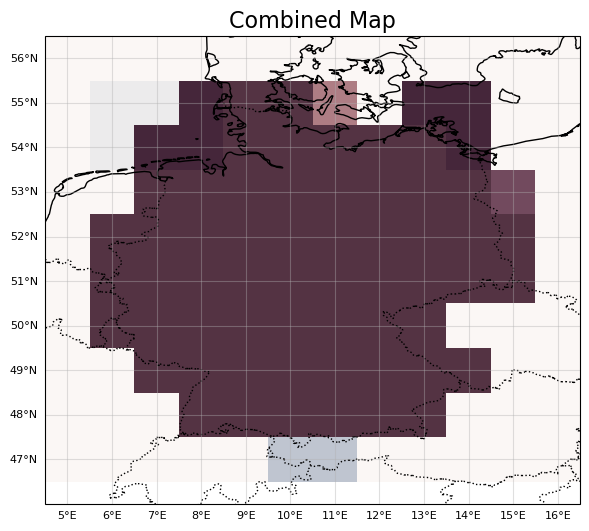

In [5]:
fig, ax = plt.subplots(figsize=(6, 6), subplot_kw={'projection': ccrs.PlateCarree()})

# Set map extent
ax.set_extent([w-1, e+1, s-1, n+1], crs=ccrs.PlateCarree())
ax.coastlines()
ax.add_feature(cfeature.BORDERS, linestyle=':', edgecolor='black')
ax.set_title('Combined Map', fontsize=16)

# Plot each layer with some transparency
im1 = ax.pcolormesh(lon_edges, lat_edges, mask_offshore, transform=ccrs.PlateCarree(), cmap='Blues', alpha=0.5)
im2 = ax.pcolormesh(lon_edges, lat_edges, mask_onshore, transform=ccrs.PlateCarree(), cmap='Greens', alpha=0.5)
im3 = ax.pcolormesh(lon_edges, lat_edges, mask_solar, transform=ccrs.PlateCarree(), cmap='Blues', alpha=0.5)
im4 = ax.pcolormesh(lon_edges, lat_edges, mask_population, transform=ccrs.PlateCarree(), cmap='Reds', alpha=0.5)

# Add gridlines
setup_gridlines(ax)

plt.tight_layout()
plt.show()

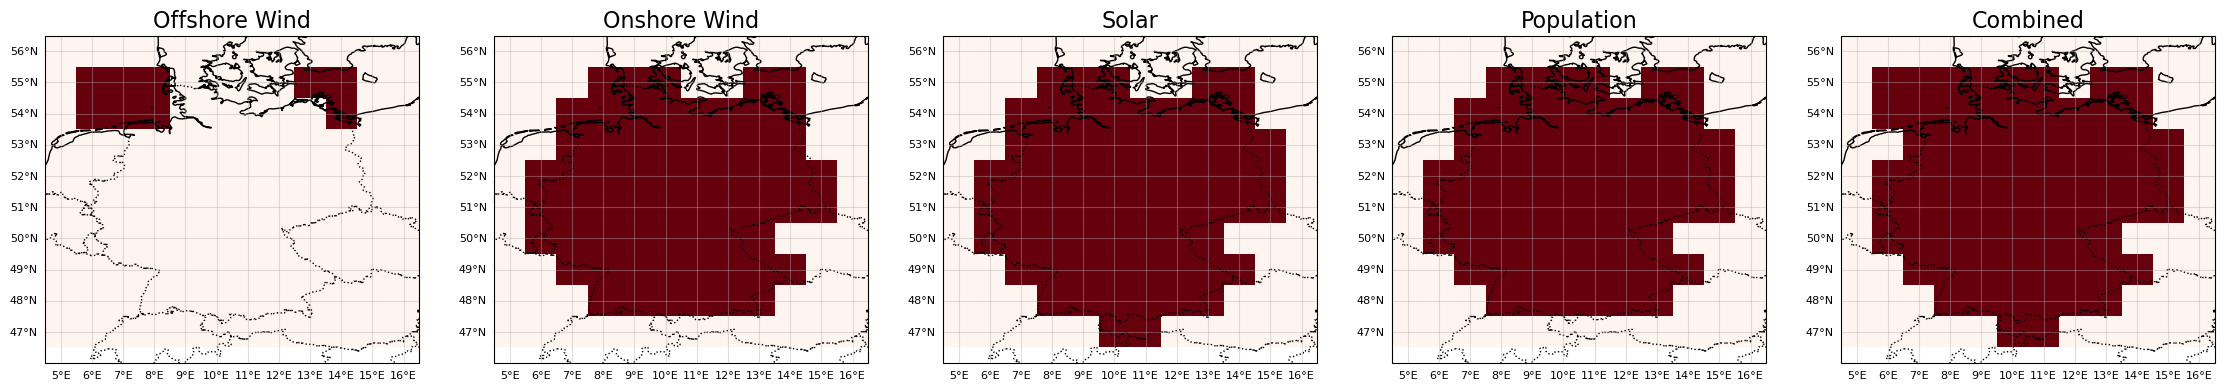

In [6]:
fig, axs = plt.subplots(1,5, figsize=(28, 8), subplot_kw={'projection': ccrs.PlateCarree()})
masks = [mask_offshore, mask_onshore, mask_solar, mask_population, overall_mask]
titles = ['Offshore Wind', 'Onshore Wind', 'Solar', 'Population', 'Combined']
for ax, m, titles in zip(axs.flat, masks, titles):
    ax.set_extent([w-1, e+1, s-1, n+1], crs=ccrs.PlateCarree()) #[5, 16, 47, 56]
    ax.coastlines()
    ax.add_feature(cfeature.BORDERS, linestyle=':', edgecolor='black')
    ax.set_title(f'{titles}', fontsize=16)
    
    # Plot the data
    im = ax.pcolormesh(lon_edges, lat_edges, m, transform=ccrs.PlateCarree(), cmap='Reds')
    
    # Add gridlines and colorbar
    setup_gridlines(ax)
    # cbar = fig.colorbar(im, ax=ax, orientation='horizontal', pad=0.05, shrink=0.7, aspect=50)

plt.show()

### Define used models

In [7]:
# Load climate data

MIP = 'ScenarioMIP' # CMIP
Institution = '*'
# ESMs = ['ACCESS-CM2', 'BCC-CSM2-MR', 'CESM2', 'CESM2-WACCM', 'CNRM-CM6-1', 'CNRM-CM6-1-HR', 'CNRM-ESM2-1', 'EC-Earth3', 'EC-Earth3-Veg', 'GFDL-CM4', 'GFDL-ESM4', 'HadGEM3-GC31-LL', 'HadGEM3-GC31-MM', 'MPI-ESM1-2-HR',
#            'MRI-ESM2-0', 'KACE-1-0-G', 'TaiESM1', 'UKESM1-0-LL']
ESMs = ['ACCESS-CM2', 'BCC-CSM2-MR', 'CESM2', 'EC-Earth3', 'GFDL-ESM4', 'MPI-ESM1-2-HR', 'MRI-ESM2-0', 'KACE-1-0-G', 'TaiESM1', 'UKESM1-0-LL'] # 'EC-Earth3-Veg'
# ESMs = ['ACCESS-CM2'] # 'EC-Earth3-Veg'

# ESMs = ['UKESM1-0-LL']
# ESMs = ['TaiEMS1', 'UKESM1-0LL']
scenario = 'ssp370'
# run = 'r1i1p1f1'
time_res = 'day'
variables = ['sfcWind', 'rsds', 'tas', 'tasmax'] # List of variables
grid_def = '*'
version = '*'


### Calculate mean timeseries per model

In [8]:
# Takes about 
for ESM in ESMs:
    print('ESM: ', ESM)
    path = f'/climca/data/CMIP6/{MIP}/{Institution}/{ESM}/{scenario}/'
    matching_dirs = glob.glob(path)
    if len(matching_dirs) == 1:
        runs = os.listdir(matching_dirs[0])
        # continue # Only for the last model
    elif len(matching_dirs) >= 1:
        runs = os.listdir(matching_dirs[0]) + os.listdir(matching_dirs[1])
    else:
        print(f"Found {len(matching_dirs)} matching directories for {ESM} and {scenario}")
        break
    print('Runs: ', runs)
    for run in runs:
        ds_list = [] # List to hold individual datasets (one for each variable)

        run_time = time.time()
        print('Run: ', run, 'Number: ', runs.index(run) + 1, 'of ', len(runs))
        run_path = os.path.join(matching_dirs[0], run, 'day/') # Watch out for last model (then manually change to matching_dirs[1])
        
        # Check if all required folders (in `variables`) exist
        missing_folders = [var for var in variables if not os.path.isdir(os.path.join(run_path, var))]
        
        if missing_folders:
            print(f"Missing folders in {run_path}: {missing_folders}")
            continue
        
        missing_data = [
            var for var in variables 
            if not os.path.isdir(os.path.join(run_path, var)) or 
               not any(
                   os.path.isfile(f) 
                   for f in glob.glob(os.path.join(run_path, var, '*', '*', '*'))  # glob pattern to match files two levels down
               )
        ]
        
        if missing_data:
            print(f"Missing data in {run_path}: {missing_data}")
            continue
        
        for variable in variables:
            # print('Variable: ', variable)
            #path =f'/climca/data/CMIP6/CMIP/NCAR/{ESM}/{scenario}/{run}/day/{variable}/gn/v20190308/{variable}_day_{ESM}_{scenario}_{run}_gn_*'
            path = f'/climca/data/CMIP6/{MIP}/{Institution}/{ESM}/{scenario}/{run}/{time_res}/{variable}/{grid_def}/{version}/{variable}_{time_res}_{ESM}_{scenario}_{run}_*'
            # print('Open: ', path)
            
            # Filter out files with extensions after .nc
            files = [f for f in glob.glob(path) if f.endswith('.nc')]
            
            # Open with preprocessing (spatial filtering)
            if files:
                nc = xr.open_mfdataset(files, preprocess=grid_func.preprocess)
            else:
                print("No valid .nc files found!")
            # nc = xr.open_mfdataset(path, preprocess=grid_func.preprocess)
                
        #     # Keep only the desired variable, but retain Dataset structure
            nc = nc[[variable]]

            # Filter years
            nc = nc.sel(time=nc.time.dt.year.isin(range(2015, 2025)))

        #     # Append to list for later merging
            ds_list.append(nc)
            
            ds_list = [ds.drop_vars('height') if 'height' in ds.coords else ds for ds in ds_list]

        # # Combine all into a single dataset
        clim_ds = xr.merge(ds_list)
                
        if ds_list[2]['tas'].units == 'K':
            clim_ds['tas'] = clim_ds['tas'] - 273.15
        
        if ds_list[3]['tasmax'].units == 'K':
            clim_ds['tasmax'] = clim_ds['tasmax'] - 273.15
        
        # Regrid the combined dataset
        combined_ds = grid_func.regrid(clim_ds)
        
        timeseries_ds = xr.Dataset()

        # Calculate the mean for each variable
        # timeseries_ds['sfcWind'] = combined_ds['sfcWind'].mean(dim=['lat', 'lon'])
        # timeseries_ds['rsds'] = combined_ds['rsds'].mean(dim=['lat', 'lon'])
        # timeseries_ds['tas'] = combined_ds['tas'].mean(dim=['lat', 'lon'])
        # timeseries_ds['tasmax'] = combined_ds['tasmax'].mean(dim=['lat', 'lon'])

        timeseries_ds['sfcWind_masked'] = combined_ds['sfcWind'].where(overall_mask == 1).mean(dim=['lat', 'lon'], skipna=True)
        timeseries_ds['rsds_masked']    = combined_ds['rsds'].where(overall_mask == 1).mean(dim=['lat', 'lon'], skipna=True)
        timeseries_ds['tas_masked']     = combined_ds['tas'].where(overall_mask == 1).mean(dim=['lat', 'lon'], skipna=True)
        timeseries_ds['tasmax_masked']  = combined_ds['tasmax'].where(overall_mask == 1).mean(dim=['lat', 'lon'], skipna=True)
        
        # Calculate the mean for each masked variable
        # timeseries_ds['sfcWind_off_masked'] = (combined_ds['sfcWind'] * mask_offshore).mean(dim=['lat', 'lon'])
        # timeseries_ds['sfcWind_on_masked'] = (combined_ds['sfcWind'] * mask_onshore).mean(dim=['lat', 'lon'])
        # timeseries_ds['rsds_masked'] = (combined_ds['rsds'] * mask_solar).mean(dim=['lat', 'lon'])

        ts_output = timeseries_ds.assign_coords(run = run, ESM = ESM, ESM_run = f'{ESM}_{run}')

        # print('Load')
        ts_output.load()
        # print('Saving')
        # ts_output.to_netcdf(f'/climca/people/onennecke/model_output/var_means/full_year/{ESM}_{run}_timeseries.nc')
        ts_output.to_netcdf(f'/climca/people/onennecke/model_output/var_means_masked/full_year/{ESM}_{run}_timeseries.nc')
        
        print('Run time: ', int(np.floor((time.time()  - run_time) / 60)),'m', round((time.time()  - run_time) % 60,1),'s')
        # print('Finished saving')
    #     break
    # break

ESM:  ACCESS-CM2
Runs:  ['r4i1p1f1', 'r5i1p1f1', 'r1i1p1f1']
Run:  r4i1p1f1 Number:  1 of  3
Run time:  2 m 3.2 s
Run:  r5i1p1f1 Number:  2 of  3
Run time:  2 m 0.1 s
Run:  r1i1p1f1 Number:  3 of  3
Run time:  2 m 7.9 s
ESM:  BCC-CSM2-MR
Runs:  ['r1i1p1f1']
Run:  r1i1p1f1 Number:  1 of  1
Run time:  0 m 0.9 s
ESM:  CESM2
Runs:  ['r4i1p1f1', 'r10i1p1f1', 'r11i1p1f1']
Run:  r4i1p1f1 Number:  1 of  3


/home/onennecke/.conda/envs/env_ma_on/lib/python3.12/site-packages/xarray/conventions.py:200: SerializationWarning: variable 'sfcWind' has multiple fill values {np.float32(1e+20), np.float64(1e+20)} defined, decoding all values to NaN.
  var = coder.decode(var, name=name)
/home/onennecke/.conda/envs/env_ma_on/lib/python3.12/site-packages/xarray/conventions.py:200: SerializationWarning: variable 'rsds' has multiple fill values {np.float32(1e+20), np.float64(1e+20)} defined, decoding all values to NaN.
  var = coder.decode(var, name=name)
/home/onennecke/.conda/envs/env_ma_on/lib/python3.12/site-packages/xarray/conventions.py:200: SerializationWarning: variable 'tas' has multiple fill values {np.float32(1e+20), np.float64(1e+20)} defined, decoding all values to NaN.
  var = coder.decode(var, name=name)
/home/onennecke/.conda/envs/env_ma_on/lib/python3.12/site-packages/xarray/conventions.py:200: SerializationWarning: variable 'tasmax' has multiple fill values {np.float32(1e+20), np.float6

Run time:  1 m 37.9 s
Run:  r10i1p1f1 Number:  2 of  3


/home/onennecke/.conda/envs/env_ma_on/lib/python3.12/site-packages/xarray/conventions.py:200: SerializationWarning: variable 'sfcWind' has multiple fill values {np.float32(1e+20), np.float64(1e+20)} defined, decoding all values to NaN.
  var = coder.decode(var, name=name)
/home/onennecke/.conda/envs/env_ma_on/lib/python3.12/site-packages/xarray/conventions.py:200: SerializationWarning: variable 'rsds' has multiple fill values {np.float32(1e+20), np.float64(1e+20)} defined, decoding all values to NaN.
  var = coder.decode(var, name=name)
/home/onennecke/.conda/envs/env_ma_on/lib/python3.12/site-packages/xarray/conventions.py:200: SerializationWarning: variable 'tas' has multiple fill values {np.float32(1e+20), np.float64(1e+20)} defined, decoding all values to NaN.
  var = coder.decode(var, name=name)
/home/onennecke/.conda/envs/env_ma_on/lib/python3.12/site-packages/xarray/conventions.py:200: SerializationWarning: variable 'tasmax' has multiple fill values {np.float32(1e+20), np.float6

Run time:  1 m 37.4 s
Run:  r11i1p1f1 Number:  3 of  3


/home/onennecke/.conda/envs/env_ma_on/lib/python3.12/site-packages/xarray/conventions.py:200: SerializationWarning: variable 'sfcWind' has multiple fill values {np.float32(1e+20), np.float64(1e+20)} defined, decoding all values to NaN.
  var = coder.decode(var, name=name)
/home/onennecke/.conda/envs/env_ma_on/lib/python3.12/site-packages/xarray/conventions.py:200: SerializationWarning: variable 'rsds' has multiple fill values {np.float32(1e+20), np.float64(1e+20)} defined, decoding all values to NaN.
  var = coder.decode(var, name=name)
/home/onennecke/.conda/envs/env_ma_on/lib/python3.12/site-packages/xarray/conventions.py:200: SerializationWarning: variable 'tas' has multiple fill values {np.float32(1e+20), np.float64(1e+20)} defined, decoding all values to NaN.
  var = coder.decode(var, name=name)
/home/onennecke/.conda/envs/env_ma_on/lib/python3.12/site-packages/xarray/conventions.py:200: SerializationWarning: variable 'tasmax' has multiple fill values {np.float32(1e+20), np.float6

Run time:  1 m 41.2 s
ESM:  EC-Earth3
Runs:  ['r149i1p1f1', 'r6i1p1f1', 'r4i1p1f1', 'r148i1p1f1', 'r105i1p1f1', 'r9i1p1f1', 'r134i1p1f1', 'r141i1p1f1', 'r146i1p1f1', 'r15i1p1f1', 'r112i1p1f1', 'r117i1p1f1', 'r125i1p1f1', 'r113i1p1f1', 'r106i1p1f1', 'r138i1p1f1', 'r5i1p1f1', 'r137i1p1f1', 'r11i1p1f1', 'r145i1p1f1', 'r114i1p1f1', 'r120i1p1f1', 'r128i1p1f1', 'r135i1p1f1', 'r110i1p1f1', 'r129i1p1f1', 'r132i1p1f1', 'r101i1p1f1', 'r124i1p1f1', 'r127i1p1f1', 'r116i1p1f1', 'r131i1p1f1', 'r121i1p1f1', 'r142i1p1f1', 'r102i1p1f1', 'r133i1p1f1', 'r111i1p1f1', 'r140i1p1f1', 'r136i1p1f1', 'r108i1p1f1', 'r130i1p1f1', 'r150i1p1f1', 'r104i1p1f1', 'r118i1p1f1', 'r109i1p1f1', 'r143i1p1f1', 'r147i1p1f1', 'r126i1p1f1', 'r13i1p1f1', 'r119i1p1f1', 'r1i1p1f1', 'r123i1p1f1', 'r122i1p1f1', 'r115i1p1f1', 'r103i1p1f1', 'r144i1p1f1', 'r139i1p1f1', 'r107i1p1f1']
Run:  r149i1p1f1 Number:  1 of  58
Run time:  2 m 47.3 s
Run:  r6i1p1f1 Number:  2 of  58
Missing data in /climca/data/CMIP6/ScenarioMIP/EC-Earth-Consortiu

In [9]:
# Takes about 
for ESM in ESMs:
    print('ESM: ', ESM)
    path = f'/climca/data/CMIP6/{MIP}/{Institution}/{ESM}/{scenario}/'
    matching_dirs = glob.glob(path)
    if len(matching_dirs) == 1:
        runs = os.listdir(matching_dirs[0])
        continue # Only for the last model
    elif len(matching_dirs) >= 1:
        runs = os.listdir(matching_dirs[0]) + os.listdir(matching_dirs[1])
    else:
        print(f"Found {len(matching_dirs)} matching directories for {ESM} and {scenario}")
        break
    print('Runs: ', runs)
    for run in runs:
        ds_list = [] # List to hold individual datasets (one for each variable)

        run_time = time.time()
        print('Run: ', run, 'Number: ', runs.index(run) + 1, 'of ', len(runs))
        run_path = os.path.join(matching_dirs[1], run, 'day/') # Watch out for last model (then manually change to matching_dirs[1])
        
        # Check if all required folders (in `variables`) exist
        missing_folders = [var for var in variables if not os.path.isdir(os.path.join(run_path, var))]
        
        if missing_folders:
            print(f"Missing folders in {run_path}: {missing_folders}")
            continue
        
        missing_data = [
            var for var in variables 
            if not os.path.isdir(os.path.join(run_path, var)) or 
               not any(
                   os.path.isfile(f) 
                   for f in glob.glob(os.path.join(run_path, var, '*', '*', '*'))  # glob pattern to match files two levels down
               )
        ]
        
        if missing_data:
            print(f"Missing data in {run_path}: {missing_data}")
            continue
        
        for variable in variables:
            # print('Variable: ', variable)
            #path =f'/climca/data/CMIP6/CMIP/NCAR/{ESM}/{scenario}/{run}/day/{variable}/gn/v20190308/{variable}_day_{ESM}_{scenario}_{run}_gn_*'
            path = f'/climca/data/CMIP6/{MIP}/{Institution}/{ESM}/{scenario}/{run}/{time_res}/{variable}/{grid_def}/{version}/{variable}_{time_res}_{ESM}_{scenario}_{run}_*'
            # print('Open: ', path)
            
            # Filter out files with extensions after .nc
            files = [f for f in glob.glob(path) if f.endswith('.nc')]
            
            # Open with preprocessing (spatial filtering)
            if files:
                nc = xr.open_mfdataset(files, preprocess=grid_func.preprocess)
            else:
                print("No valid .nc files found!")
            # nc = xr.open_mfdataset(path, preprocess=grid_func.preprocess)
                
        #     # Keep only the desired variable, but retain Dataset structure
            nc = nc[[variable]]

            # Filter years
            nc = nc.sel(time=nc.time.dt.year.isin(range(2015, 2025)))

        #     # Append to list for later merging
            ds_list.append(nc)
            
            ds_list = [ds.drop_vars('height') if 'height' in ds.coords else ds for ds in ds_list]

        # # Combine all into a single dataset
        clim_ds = xr.merge(ds_list)
                
        if ds_list[2]['tas'].units == 'K':
            clim_ds['tas'] = clim_ds['tas'] - 273.15
        
        if ds_list[3]['tasmax'].units == 'K':
            clim_ds['tasmax'] = clim_ds['tasmax'] - 273.15
        
        # Regrid the combined dataset
        combined_ds = grid_func.regrid(clim_ds)
        
        timeseries_ds = xr.Dataset()

        # Calculate the mean for each variable
        # timeseries_ds['sfcWind'] = combined_ds['sfcWind'].mean(dim=['lat', 'lon'])
        # timeseries_ds['rsds'] = combined_ds['rsds'].mean(dim=['lat', 'lon'])
        # timeseries_ds['tas'] = combined_ds['tas'].mean(dim=['lat', 'lon'])
        # timeseries_ds['tasmax'] = combined_ds['tasmax'].mean(dim=['lat', 'lon'])
        
        timeseries_ds['sfcWind_masked'] = combined_ds['sfcWind'].where(overall_mask == 1).mean(dim=['lat', 'lon'], skipna=True)
        timeseries_ds['rsds_masked']    = combined_ds['rsds'].where(overall_mask == 1).mean(dim=['lat', 'lon'], skipna=True)
        timeseries_ds['tas_masked']     = combined_ds['tas'].where(overall_mask == 1).mean(dim=['lat', 'lon'], skipna=True)
        timeseries_ds['tasmax_masked']  = combined_ds['tasmax'].where(overall_mask == 1).mean(dim=['lat', 'lon'], skipna=True)
        
        # Calculate the mean for each masked variable
        # timeseries_ds['sfcWind_off_masked'] = (combined_ds['sfcWind'] * mask_offshore).mean(dim=['lat', 'lon'])
        # timeseries_ds['sfcWind_on_masked'] = (combined_ds['sfcWind'] * mask_onshore).mean(dim=['lat', 'lon'])
        # timeseries_ds['rsds_masked'] = (combined_ds['rsds'] * mask_solar).mean(dim=['lat', 'lon'])

        ts_output = timeseries_ds.assign_coords(run = run, ESM = ESM, ESM_run = f'{ESM}_{run}')

        # print('Load')
        ts_output.load()
        # print('Saving')
        # ts_output.to_netcdf(f'/climca/people/onennecke/model_output/var_means/full_year/{ESM}_{run}_timeseries.nc')
        ts_output.to_netcdf(f'/climca/people/onennecke/model_output/var_means_masked/full_year/{ESM}_{run}_timeseries.nc')
        
        print('Run time: ', int(np.floor((time.time()  - run_time) / 60)),'m', round((time.time()  - run_time) % 60,1),'s')
        # print('Finished saving')
    #     break
    # break

ESM:  ACCESS-CM2
ESM:  BCC-CSM2-MR
ESM:  CESM2
ESM:  EC-Earth3
ESM:  GFDL-ESM4
ESM:  MPI-ESM1-2-HR
ESM:  MRI-ESM2-0
ESM:  KACE-1-0-G
ESM:  TaiESM1
ESM:  UKESM1-0-LL
Runs:  ['r4i1p1f2', 'r19i1p1f2', 'r12i1p1f2', 'r1i1p1f2', 'r18i1p1f2', 'r16i1p1f2', 'r9i1p1f2', 'r7i1p1f2', 'r11i1p1f2', 'r6i1p1f2', 'r2i1p1f2', 'r10i1p1f2', 'r17i1p1f2', 'r5i1p1f2', 'r3i1p1f2', 'r8i1p1f2', 'r15i1p1f2', 'r13i1p1f2', 'r14i1p1f2']
Run:  r4i1p1f2 Number:  1 of  19
Missing folders in /climca/data/CMIP6/ScenarioMIP/NIMS-KMA/UKESM1-0-LL/ssp370/r4i1p1f2/day/: ['sfcWind', 'rsds', 'tas', 'tasmax']
Run:  r19i1p1f2 Number:  2 of  19
Missing folders in /climca/data/CMIP6/ScenarioMIP/NIMS-KMA/UKESM1-0-LL/ssp370/r19i1p1f2/day/: ['sfcWind', 'rsds', 'tas', 'tasmax']
Run:  r12i1p1f2 Number:  3 of  19
Missing folders in /climca/data/CMIP6/ScenarioMIP/NIMS-KMA/UKESM1-0-LL/ssp370/r12i1p1f2/day/: ['sfcWind', 'rsds', 'tas', 'tasmax']
Run:  r1i1p1f2 Number:  4 of  19
Missing folders in /climca/data/CMIP6/ScenarioMIP/NIMS-KMA/UKES

In [77]:
ts_output 


<xarray.Dataset> Size: 173kB
Dimensions:             (time: 3600)
Coordinates:
  * time                (time) object 29kB 2015-01-01 12:00:00 ... 2024-12-30...
    crs                 int64 8B 4326
    gridtype            <U6 24B 'lonlat'
    run                 <U9 36B 'r15i1p1f2'
    ESM                 <U11 44B 'UKESM1-0-LL'
    ESM_run             <U21 84B 'UKESM1-0-LL_r15i1p1f2'
Data variables:
    sfcWind             (time) float32 14kB 4.975 4.531 5.331 ... 5.805 6.307
    rsds                (time) float32 14kB 16.09 13.74 15.98 ... 13.69 11.95
    tas                 (time) float32 14kB 0.8185 2.441 2.055 ... 3.077 4.706
    tasmax              (time) float32 14kB 3.104 3.556 3.071 ... 5.163 5.869
    sfcWind_off_masked  (time) float64 29kB 0.6986 0.5434 ... 0.7593 0.741
    sfcWind_on_masked   (time) float64 29kB 2.777 2.494 3.13 ... 3.302 3.795
    rsds_masked         (time) float64 29kB 9.611 6.841 8.809 ... 7.822 6.816

In [10]:
# Same for ERA5
variable = 't2m'
variables = ['U100', 'V100', 'SSRD', 'tas', 'tmax'] # List of variables
# path = f'/climca/data/ERA5/daily/{variables[3]}/' # Only for tmax und zum checken der anderen Variablen
path = '/climca/people/ppfleiderer/ERA5/RL_climate/ERA5_raw/*'
matching_dirs = glob.glob(path)
all_files = [f for f in glob.glob(path) if f.endswith('.nc')]
all_files = sorted(all_files)
# Select all files in the range 2014-2024
path = '/climca/people/ppfleiderer/ERA5/RL_climate/ERA5_raw/*'
year_range = (2015, 2024)
all_files = [f for f in glob.glob(path) if f.endswith('.nc')]
all_files = sorted(all_files)

filtered_files = []
for file in all_files:
    # Extract year and month using regex
    match = re.search(r'(\d{4})', file)
    if match:
        year = int(match.group(1))
        if year_range is None or year_range[0] <= year <= year_range[1]:
            filtered_files.append(file)

filtered_files

# Read datasets for each variable
files_by_variable = {}

# Group files by variable name
for f in filtered_files:
    match = re.search(r'/([^/]+)_(\d{4})\.nc$', f)
    if match:
        var = match.group(1)
        if var not in files_by_variable:
            files_by_variable[var] = []
        files_by_variable[var].append(f)

files_by_variable
# SSRD_list = files_by_variable['SSRD']
# SSRD_list

# Read datasets for each variable
datasets_by_variable = {}
for var, files in files_by_variable.items():
    # print(f'Processing {var}...')
    files_sorted = sorted(files)

    # Use the first file as coordinate reference
    ref_ds = xr.open_dataset(files_sorted[0])
    ref_lat = ref_ds.lat
    ref_lon = ref_ds.lon

    def preprocess(ds):
        ds = ds.sortby('lat')  # Ensure consistent order
        ds = ds.assign_coords(lat=ref_lat, lon=ref_lon)  # Align coordinates exactly
        return ds

    # Open and process all datasets with aligned coordinates
    ds = xr.open_mfdataset(files_sorted, combine='by_coords', preprocess=preprocess)
    
    if var == 'SSRD':
        ds = ds / 3600 # Convert from J/m2 to W/m2
    ds_daily = ds.resample(time='1D').mean()
    datasets_by_variable[var] = ds_daily
    if var == 'tas':
        tasmax = ds.resample(time='1D').max()
        tasmax = tasmax.rename({'var167': 'tasmax'})
        datasets_by_variable['tasmax'] = tasmax


datasets_by_variable

var_names = {'var169': 'rsds',
             'var167': 'tas',
             'var246': 'U100',
             'var247': 'V100',
             'tasmax': 'tasmax'}

ds_list = []

for i in datasets_by_variable:
    # print(i)
    # print(datasets_by_variable[i])
    # print('------------------')
    ds = datasets_by_variable[i]
    var = list(ds.data_vars)[0]
    ds = ds.rename({var: var_names[var]})
    ds = ds.sel(lat=slice(45, 60), lon=slice(4, 17))
    nc = grid_func.regrid(ds, s = 47, n = 56, w = 5, e = 17) # One ° less in the north to prevent NaN values
    # Append to list for later merging
    ds_list.append(nc)
    # ds.to_netcdf(f'/climca/people/onennecke/ERA5/{i}.nc')

# Read in tmax

# Combine all into a single dataset
clim_ds = xr.merge(ds_list)

clim_ds['wind_speed'] = np.sqrt(clim_ds['U100']**2 + clim_ds['V100']**2)
clim_ds['tas'] = clim_ds['tas'] - 273.15
clim_ds['tasmax'] = clim_ds['tasmax'] - 273.15

combined_ds = clim_ds
combined_ds

timeseries_ds = xr.Dataset()

timeseries_ds['sfcWind_masked'] = combined_ds['wind_speed'].where(overall_mask == 1).mean(dim=['lat', 'lon'], skipna=True)
timeseries_ds['rsds_masked']    = combined_ds['rsds'].where(overall_mask == 1).mean(dim=['lat', 'lon'], skipna=True)
timeseries_ds['tas_masked']     = combined_ds['tas'].where(overall_mask == 1).mean(dim=['lat', 'lon'], skipna=True)
timeseries_ds['tasmax_masked']  = combined_ds['tasmax'].where(overall_mask == 1).mean(dim=['lat', 'lon'], skipna=True)

# timeseries_ds['sfcWind'] = combined_ds['wind_speed'].mean(dim=['lat', 'lon'])
# timeseries_ds['rsds'] = combined_ds['rsds'].mean(dim=['lat', 'lon'])
# timeseries_ds['tas'] = combined_ds['tas'].mean(dim=['lat', 'lon'])
# timeseries_ds['tasmax'] = combined_ds['tasmax'].mean(dim=['lat', 'lon'])

# # Calculate the mean for each masked variable
# timeseries_ds['sfcWind_off_masked'] = (combined_ds['wind_speed'] * mask_offshore).mean(dim=['lat', 'lon'])
# timeseries_ds['sfcWind_on_masked'] = (combined_ds['wind_speed'] * mask_onshore).mean(dim=['lat', 'lon'])
# timeseries_ds['rsds_masked'] = (combined_ds['rsds'] * mask_solar).mean(dim=['lat', 'lon'])

ts_output = timeseries_ds.assign_coords(run = 'hist', ESM = 'ERA5', ESM_run = 'ERA5_hist') # , country = 9.0, period = 'week'
# print('Load')
ts_output.load()
# print('Saving')
ts_output.to_netcdf('/climca/people/onennecke/model_output/var_means_masked/full_year/ERA5_timeseries.nc')


# print('Finished saving')


In [11]:
ts_output

<xarray.Dataset> Size: 88kB
Dimensions:         (time: 3653)
Coordinates:
  * time            (time) datetime64[ns] 29kB 2015-01-01 ... 2024-12-31
    crs             int64 8B 4326
    gridtype        <U6 24B 'lonlat'
    country         float64 8B 9.0
    run             <U4 16B 'hist'
    ESM             <U4 16B 'ERA5'
    ESM_run         <U9 36B 'ERA5_hist'
Data variables:
    sfcWind_masked  (time) float32 15kB 7.507 11.86 9.267 ... 6.159 8.049 8.775
    rsds_masked     (time) float32 15kB 30.54 19.51 17.85 ... 28.84 26.3 31.92
    tas_masked      (time) float32 15kB 1.771 3.587 3.046 ... 0.2238 1.512 1.194
    tasmax_masked   (time) float32 15kB 3.431 5.871 4.704 ... 2.446 2.709 3.361

----

### Calculate winter time format

In [12]:
# path = '/climca/people/onennecke/model_output/var_means/full_year/'
path = '/climca/people/onennecke/model_output/var_means_masked/full_year/'

# files = glob.glob(os.path.join(path, '*.nc'))
files = sorted(glob.glob(os.path.join(path, '*.nc')))
files = files[:60] + files[61:] # Exclude the ERA5 file
len(files)
# files

99

In [13]:
ts_ds_in = xr.open_dataset(files[0])
ts_ds_win_in = winter_date_func.add_winter_calendar(ts_ds_in)
ts_win_in = ts_ds_win_in.sel(time=ts_ds_win_in['day_of_winter'].isin(range(1, 183)))


for i in files:
    print(i)
    ts_ds = xr.open_dataset(i)
    ts_ds_win = winter_date_func.add_winter_calendar(ts_ds)
    ts_win = ts_ds_win.sel(time=ts_ds_win['day_of_winter'].isin(range(1, 183)))
    # ts_win = ts_win.assign_coords(old_time=ts_win.time)
    if isinstance(ts_win.time.values[0], cftime.Datetime360Day):
        print('Time format is cftime.Datetime360Day')
        cut = ts_win.isel(time = slice(2, None))
        last_day = ts_win.isel(time=-1)
        long = xr.concat([cut, last_day, last_day], dim='time')
        # Fix day_of_winter and winter_season for the two new padded days
        day_of_winter = long['day_of_winter'].values
        day_of_winter[-2] = 91
        day_of_winter[-1] = 92

        winter_year = long['winter_year'].values
        winter_season = np.array([f"{y}-{d:03d}" for y, d in zip(winter_year, day_of_winter)])

        # Reassign corrected coordinates
        ts_win = long.assign_coords(
            day_of_winter=('time', day_of_winter),
            winter_season=('time', winter_season)
        )
    if ts_win.time.dtype != 'datetime64[ns]':
        print('Time format is not datetime64[ns]')
        ts_win = ts_win.assign_coords({'time': ('time', ts_win_in.time.values)})
    print(len(ts_win.sel(time=ts_win['winter_year']==2014).time.values))
    # ts_win.to_netcdf('/climca/people/onennecke/model_output/var_means/winter_data/' + i[58:-3] + '_win.nc')
    ts_win.to_netcdf('/climca/people/onennecke/model_output/var_means_masked/winter_data/' + i[65:-3] + '_win.nc')


# print(ts_win.ESM_run.values)
# ts_win

/climca/people/onennecke/model_output/var_means_masked/full_year/ACCESS-CM2_r1i1p1f1_timeseries.nc
90
/climca/people/onennecke/model_output/var_means_masked/full_year/ACCESS-CM2_r4i1p1f1_timeseries.nc
90
/climca/people/onennecke/model_output/var_means_masked/full_year/ACCESS-CM2_r5i1p1f1_timeseries.nc
90
/climca/people/onennecke/model_output/var_means_masked/full_year/BCC-CSM2-MR_r1i1p1f1_timeseries.nc
Time format is not datetime64[ns]
90
/climca/people/onennecke/model_output/var_means_masked/full_year/CESM2_r10i1p1f1_timeseries.nc
Time format is not datetime64[ns]
90
/climca/people/onennecke/model_output/var_means_masked/full_year/CESM2_r11i1p1f1_timeseries.nc
Time format is not datetime64[ns]
90
/climca/people/onennecke/model_output/var_means_masked/full_year/CESM2_r4i1p1f1_timeseries.nc
Time format is not datetime64[ns]
90
/climca/people/onennecke/model_output/var_means_masked/full_year/EC-Earth3_r101i1p1f1_timeseries.nc
90
/climca/people/onennecke/model_output/var_means_masked/full

In [14]:
files = '/climca/people/onennecke/model_output/var_means_masked/full_year/ERA5_timeseries.nc'
# files = '/climca/people/onennecke/model_output/var_means/full_year/ERA5_timeseries.nc'

ts_ds_ERA5 = xr.open_dataset(files)
ts_ds_win_ERA5 = winter_date_func.add_winter_calendar(ts_ds_ERA5)
ts_win_ERA5 = ts_ds_win_ERA5.sel(time=ts_ds_win_ERA5['day_of_winter'].isin(range(1, 183)))

## Fix time format for ERA5
ts_win_ERA5 = ts_win_ERA5.assign_coords(time=ts_win['time'].values)

ts_win_ERA5.to_netcdf('/climca/people/onennecke/model_output/var_means_masked/winter_data/' + files[65:-3] + '_win.nc')
# ts_win_ERA5.to_netcdf('/climca/people/onennecke/model_output/var_means/winter_data/' + files[58:-3] + '_win.nc')



In [15]:
# files = '/climca/people/onennecke/model_output/var_means/winter_data/ERA5_timeseries_win.nc'
files = '/climca/people/onennecke/model_output/var_means_masked/winter_data/ERA5_timeseries_win.nc'

ts_ds_ERA5 = xr.open_dataset(files)
ts_ds_ERA5

<xarray.Dataset> Size: 131kB
Dimensions:         (time: 1820)
Coordinates:
    crs             int64 8B ...
    gridtype        <U6 24B ...
    country         float64 8B ...
    run             <U4 16B ...
    ESM             <U4 16B ...
    ESM_run         <U9 36B ...
    winter_year     (time) int64 15kB ...
    day_of_winter   (time) int64 15kB ...
    winter_season   (time) <U8 58kB ...
  * time            (time) datetime64[ns] 15kB 2015-01-01T12:00:00 ... 2024-1...
Data variables:
    sfcWind_masked  (time) float32 7kB ...
    rsds_masked     (time) float32 7kB ...
    tas_masked      (time) float32 7kB ...
    tasmax_masked   (time) float32 7kB ...

----

### Calculate Model Bias

In [16]:
# path = '/climca/people/onennecke/model_output/var_means/winter_data/'
path = '/climca/people/onennecke/model_output/var_means_masked/winter_data/'

files = sorted(glob.glob(os.path.join(path, '*.nc')))
# files = files[:60] + files[61:]
ts_datasets = xr.open_mfdataset(files, combine='nested', concat_dim='ESM_run')
# files

# Rename variables without _masked
ts_datasets = ts_datasets.rename({
    'sfcWind_masked': 'sfcWind',
    'rsds_masked': 'rsds',
    'tas_masked': 'tas',
    'tasmax_masked': 'tasmax'
})

ts_datasets.load()

<xarray.Dataset> Size: 3MB
Dimensions:        (ESM_run: 100, time: 1820)
Coordinates:
  * time           (time) datetime64[ns] 15kB 2015-01-01T12:00:00 ... 2024-12...
    crs            int64 8B 4326
    gridtype       <U6 24B 'lonlat'
    country        float64 8B 9.0
    run            (ESM_run) <U10 4kB 'r1i1p1f1' 'r4i1p1f1' ... 'r9i1p1f2'
    ESM            (ESM_run) <U13 5kB 'ACCESS-CM2' ... 'UKESM1-0-LL'
  * ESM_run        (ESM_run) <U23 9kB 'ACCESS-CM2_r1i1p1f1' ... 'UKESM1-0-LL_...
    winter_year    (time) int64 15kB 2014 2014 2014 2014 ... 2024 2024 2024 2024
    day_of_winter  (time) int64 15kB 93 94 95 96 97 98 99 ... 87 88 89 90 91 92
    winter_season  (time) <U8 58kB '2014-093' '2014-094' ... '2024-092'
Data variables:
    sfcWind        (ESM_run, time) float32 728kB 5.901 4.541 ... 7.229 7.229
    rsds           (ESM_run, time) float32 728kB 13.75 24.11 ... 21.48 21.48
    tas            (ESM_run, time) float32 728kB 2.114 -0.7924 ... 4.354 4.354
    tasmax         (ESM_run, time) float32 728kB 4.033 0.7523 ... 5.364 5.364

In [17]:
# Group data by ESMs and calculate mean temp, demand, wind, ...
all_dfs = []
for esm in np.unique(ts_datasets['ESM'].values):
    filtered_dataset = ts_datasets.where(ts_datasets['ESM'] == esm, drop=True)
    mean_by_day = filtered_dataset.groupby('day_of_winter').mean(dim=['time', 'ESM_run'])
    df = pd.DataFrame({
        'day_of_winter': mean_by_day['day_of_winter'].values,
        #### 'temp': mean_by_day['temp'].values,
        #### 'demand': mean_by_day['demand'].values,
        #### 'demand_weekly': mean_by_day['demand_weekly'].values,
        'sfcWind': mean_by_day['sfcWind'].values,
        'rsds' : mean_by_day['rsds'].values,
        'tas': mean_by_day['tas'].values,
        'tasmax': mean_by_day['tasmax'].values,
        #### 'wind_off_prod': mean_by_day['wind_off_prod'].values,
        #### 'wind_on_prod': mean_by_day['wind_on_prod'].values,
        #### 'solar_prod': mean_by_day['solar_prod'].values,
        #### 'total_prod': mean_by_day['total_prod'].values,
        #### 'netto': mean_by_day['Netto'].values,
        #### 'Residual_load': mean_by_day['Residual_load'].values,
    })
    df['ESM'] = esm
    all_dfs.append(df)

final_df = pd.concat(all_dfs, ignore_index=True)

final_df

,day_of_winter,sfcWind,rsds,tas,tasmax,ESM
0,1,3.076449,108.239838,12.526902,16.064705,ACCESS-CM2
1,2,3.148746,111.248367,12.309891,15.620342,ACCESS-CM2
2,3,3.000850,109.638603,11.612302,14.853293,ACCESS-CM2
3,4,2.745100,108.047859,11.301968,14.407842,ACCESS-CM2
4,5,2.823787,102.943375,10.955401,13.917099,ACCESS-CM2
...,...,...,...,...,...,...
1997,178,4.156104,131.962051,4.968937,7.827445,UKESM1-0-LL
1998,179,4.145321,131.098999,5.135975,7.938185,UKESM1-0-LL
1999,180,4.089931,130.787537,5.267053,8.050565,UKESM1-0-LL
2000,181,3.926508,138.705521,5.388343,8.320410,UKESM1-0-LL


In [18]:
# For Boxplots per model
df = ts_datasets.to_dataframe().reset_index()

variables = [
    'sfcWind', 'rsds', 'tas', 'tasmax' # , 'temp', 'demand', 'demand_weekly', 'wind_off_prod', 'wind_on_prod', 'solar_prod', 'total_prod', 'Residual_load'
]


# Compute ESM counts once and create labels
esm_counts = (df['ESM'].value_counts().sort_index() // 1820).astype(int)
esm_label_map = {esm: f"{esm} (n={count})" for esm, count in esm_counts.items()}
df['ESM_label'] = df['ESM'].map(esm_label_map)

In [19]:
all_dfs = []
for var in variables:
    ERA5_mean = ts_datasets[var].sel(ESM_run='ERA5_hist').mean('time')
    model_mean = ts_datasets[var].groupby('ESM').mean().mean('time')
    # overall_mean = ts_datasets[var].mean('time').mean()
    
    overall_mean = ts_datasets[var].mean('time').mean('ESM_run')
    
    bias = model_mean - ERA5_mean
    
    df_bias = pd.DataFrame({
        'ESM': np.unique(ts_datasets['ESM'].values),
        # 'ERA5_mean': ERA5_mean.values,
        f'model_mean_{var}': model_mean.values,
        f'overall_mean_{var}': overall_mean.values,
        f'bias_{var}': bias.values
    })
    all_dfs.append(df_bias)
final_df_bias = pd.concat(all_dfs, axis=1, ignore_index=False)
final_df_bias = final_df_bias.loc[:,~final_df_bias.columns.duplicated()]


In [20]:
# Save the DataFrame to a CSV file
# final_df_bias.to_csv('/climca/people/onennecke/model_output/var_means/biases.csv', index=False)
final_df_bias.to_csv('/climca/people/onennecke/model_output/var_means_masked/biases.csv', index=False)

In [21]:
final_df_bias

,ESM,model_mean_sfcWind,overall_mean_sfcWind,bias_sfcWind,model_mean_rsds,overall_mean_rsds,bias_rsds,model_mean_tas,overall_mean_tas,bias_tas,model_mean_tasmax,overall_mean_tasmax,bias_tasmax
0,ACCESS-CM2,4.211840,4.691658,-2.133586,53.578545,59.927299,-6.301769,3.645760,4.073766,-1.458158,5.604193,6.583297,-2.100756
1,BCC-CSM2-MR,4.831176,4.691658,-1.514250,47.889801,59.927299,-11.990513,4.574496,4.073766,-0.529422,6.677243,6.583297,-1.027706
2,CESM2,5.042759,4.691658,-1.302667,60.249096,59.927299,0.368782,6.104048,4.073766,1.000131,8.581801,6.583297,0.876853
3,EC-Earth3,4.912206,4.691658,-1.433220,61.514252,59.927299,1.633938,4.012864,4.073766,-1.091054,6.694421,6.583297,-1.010528
4,ERA5,6.345426,4.691658,0.000000,59.880314,59.927299,0.000000,5.103918,4.073766,0.000000,7.704949,6.583297,0.000000
5,GFDL-ESM4,5.159821,4.691658,-1.185605,54.001675,59.927299,-5.878639,3.609791,4.073766,-1.494126,5.608334,6.583297,-2.096615
6,KACE-1-0-G,4.991951,4.691658,-1.353475,57.075626,59.927299,-2.804688,3.792398,4.073766,-1.311519,5.882808,6.583297,-1.822141
7,MPI-ESM1-2-HR,4.628232,4.691658,-1.717194,51.053043,59.927299,-8.827271,3.627550,4.073766,-1.476367,5.897475,6.583297,-1.807474
8,MRI-ESM2-0,4.202353,4.691658,-2.143073,63.341995,59.927299,3.461681,5.751032,4.073766,0.647114,7.849053,6.583297,0.144104
9,TaiESM1,3.802679,4.691658,-2.542747,58.571175,59.927299,-1.309139,6.173880,4.073766,1.069962,9.466802,6.583297,1.761853


In [ ]:
# bias_table = pd.read_csv('/climca/people/onennecke/model_output/var_means_masked/biases.csv')
# bias_table

,ESM,model_mean_sfcWind,overall_mean_sfcWind,bias_sfcWind,model_mean_rsds,overall_mean_rsds,bias_rsds,model_mean_tas,overall_mean_tas,bias_tas,model_mean_tasmax,overall_mean_tasmax,bias_tasmax
0,ACCESS-CM2,2.456906,2.740913,-1.655870,31.254152,34.996403,-7.557161,2.126693,2.379672,-1.181402,3.269113,3.84525,-1.724836
1,BCC-CSM2-MR,2.818186,2.740913,-1.294590,27.935718,34.996403,-10.875595,2.668456,2.379672,-0.639639,3.895058,3.84525,-1.098890
2,CESM2,2.941610,2.740913,-1.171167,35.145303,34.996403,-3.666010,3.560695,2.379672,0.252600,5.006051,3.84525,0.012103
3,EC-Earth3,2.865453,2.740913,-1.247323,35.883314,34.996403,-2.927999,2.340837,2.379672,-0.967258,3.905079,3.84525,-1.088869
4,ERA5,4.112776,2.740913,0.000000,38.811313,34.996403,0.000000,3.308095,2.379672,0.000000,4.993948,3.84525,0.000000
5,GFDL-ESM4,3.009896,2.740913,-1.102881,31.500977,34.996403,-7.310336,2.105712,2.379672,-1.202383,3.271528,3.84525,-1.722420
6,KACE-1-0-G,2.911972,2.740913,-1.200805,33.294118,34.996403,-5.517195,2.212232,2.379672,-1.095862,3.431638,3.84525,-1.562310
7,MPI-ESM1-2-HR,2.699802,2.740913,-1.412974,29.780943,34.996403,-9.030370,2.116071,2.379672,-1.192024,3.440194,3.84525,-1.553754
8,MRI-ESM2-0,2.451372,2.740913,-1.661404,36.949496,34.996403,-1.861817,3.354769,2.379672,0.046674,4.578615,3.84525,-0.415334
9,TaiESM1,2.218229,2.740913,-1.894547,34.166519,34.996403,-4.644794,3.601430,2.379672,0.293335,5.522301,3.84525,0.528352


In [ ]:
# bias_table = pd.read_csv('/climca/people/onennecke/model_output/var_means/biases.csv')
# bias_table

,ESM,model_mean_sfcWind,overall_mean_sfcWind,bias_sfcWind,model_mean_rsds,overall_mean_rsds,bias_rsds,model_mean_tas,overall_mean_tas,bias_tas,model_mean_tasmax,overall_mean_tasmax,bias_tasmax
0,ACCESS-CM2,4.014467,4.758104,-2.135544,49.625160,59.40331,-13.228687,3.479837,3.990142,-1.461144,5.251128,6.394623,-2.371180
1,BCC-CSM2-MR,5.141458,4.758104,-1.008552,48.319298,59.40331,-14.534550,4.717118,3.990142,-0.223862,6.694823,6.394623,-0.927485
2,CESM2,5.130517,4.758104,-1.019494,61.252846,59.40331,-1.601002,6.068026,3.990142,1.127046,8.515442,6.394623,0.893133
3,EC-Earth3,5.070338,4.758104,-1.079672,62.321312,59.40331,-0.532536,3.966104,3.990142,-0.974877,6.581461,6.394623,-1.040848
4,ERA5,6.150011,4.758104,0.000000,62.853848,59.40331,0.000000,4.940980,3.990142,0.000000,7.622309,6.394623,0.000000
5,GFDL-ESM4,5.288215,4.758104,-0.861796,54.994446,59.40331,-7.859402,3.581616,3.990142,-1.359364,5.548703,6.394623,-2.073606
6,KACE-1-0-G,4.867587,4.758104,-1.282424,52.961823,59.40331,-9.892025,3.592714,3.990142,-1.348267,5.453710,6.394623,-2.168599
7,MPI-ESM1-2-HR,4.824796,4.758104,-1.325214,52.175550,59.40331,-10.678299,3.620838,3.990142,-1.320143,5.859036,6.394623,-1.763273
8,MRI-ESM2-0,4.517055,4.758104,-1.632956,63.668620,59.40331,0.814774,5.704361,3.990142,0.763381,7.783306,6.394623,0.160997
9,TaiESM1,4.025005,4.758104,-2.125006,59.952618,59.40331,-2.901230,6.078391,3.990142,1.137411,9.326552,6.394623,1.704244


----

### Plot to look at corrected values

In [3]:
# path = '/climca/people/onennecke/model_output/bias_corrected/winter_data/'
path = '/climca/people/onennecke/model_output/bias_corrected_masked/winter_data/'

files = sorted(glob.glob(os.path.join(path, '*.nc')))
# files = files[:60] + files[61:]
ts_datasets = xr.open_mfdataset(files, combine='nested', concat_dim='ESM_run')
# files

# Rename variables without _masked
# ts_datasets = ts_datasets.rename({
#     'sfcWind_masked': 'sfcWind',
#     'rsds_masked': 'rsds',
#     'tas_masked': 'tas',
#     'tasmax_masked': 'tasmax'
# })
ts_datasets

<xarray.Dataset> Size: 18MB
Dimensions:        (ESM_run: 101, time: 1820)
Coordinates:
  * time           (time) datetime64[ns] 15kB 2015-01-01T12:00:00 ... 2024-12...
    crs            int64 8B 4326
    gridtype       <U6 24B 'lonlat'
    country        float64 8B 9.0
    period         <U4 16B 'week'
    run            (ESM_run) <U10 4kB 'r1i1p1f1' 'r4i1p1f1' ... 'r9i1p1f2'
    ESM            (ESM_run) <U13 5kB 'ACCESS-CM2' ... 'UKESM1-0-LL'
  * ESM_run        (ESM_run) <U23 9kB 'ACCESS-CM2_r1i1p1f1' ... 'UKESM1-0-LL_...
    winter_year    (time) int64 15kB dask.array<chunksize=(1820,), meta=np.ndarray>
    day_of_winter  (time) int64 15kB dask.array<chunksize=(1820,), meta=np.ndarray>
    winter_season  (time) <U8 58kB dask.array<chunksize=(1820,), meta=np.ndarray>
Data variables:
    temp           (ESM_run, time) float64 1MB dask.array<chunksize=(1, 1820), meta=np.ndarray>
    demand         (ESM_run, time) float64 1MB dask.array<chunksize=(1, 1820), meta=np.ndarray>
    sfcWind        (ESM_run, time) float64 1MB dask.array<chunksize=(1, 1820), meta=np.ndarray>
    rsds           (ESM_run, time) float64 1MB dask.array<chunksize=(1, 1820), meta=np.ndarray>
    tas            (ESM_run, time) float64 1MB dask.array<chunksize=(1, 1820), meta=np.ndarray>
    tasmax         (ESM_run, time) float64 1MB dask.array<chunksize=(1, 1820), meta=np.ndarray>
    wind_off_prod  (ESM_run, time) float64 1MB dask.array<chunksize=(1, 1820), meta=np.ndarray>
    wind_on_prod   (ESM_run, time) float64 1MB dask.array<chunksize=(1, 1820), meta=np.ndarray>
    solar_prod     (ESM_run, time) float64 1MB dask.array<chunksize=(1, 1820), meta=np.ndarray>
    total_prod     (ESM_run, time) float64 1MB dask.array<chunksize=(1, 1820), meta=np.ndarray>
    Netto          (ESM_run, time) float64 1MB dask.array<chunksize=(1, 1820), meta=np.ndarray>
    Residual_load  (ESM_run, time) float64 1MB dask.array<chunksize=(1, 1820), meta=np.ndarray>

In [4]:
# Group data by ESMs and calculate mean temp, demand, wind, ...
all_dfs = []
for esm in np.unique(ts_datasets['ESM'].values):
    filtered_dataset = ts_datasets.where(ts_datasets['ESM'] == esm, drop=True)
    mean_by_day = filtered_dataset.groupby('day_of_winter').mean(dim=['time', 'ESM_run'])
    df = pd.DataFrame({
        'day_of_winter': mean_by_day['day_of_winter'].values,
        # 'temp': mean_by_day['temp'].values,
        # 'demand': mean_by_day['demand'].values,
        # 'demand_weekly': mean_by_day['demand_weekly'].values,
        'sfcWind': mean_by_day['sfcWind'].values,
        'rsds' : mean_by_day['rsds'].values,
        'tas': mean_by_day['tas'].values,
        'tasmax': mean_by_day['tasmax'].values,
        # 'wind_off_prod': mean_by_day['wind_off_prod'].values,
        # 'wind_on_prod': mean_by_day['wind_on_prod'].values,
        # 'solar_prod': mean_by_day['solar_prod'].values,
        # 'total_prod': mean_by_day['total_prod'].values,
        # 'netto': mean_by_day['Netto'].values,
        # 'Residual_load': mean_by_day['Residual_load'].values,
    })
    df['ESM'] = esm
    all_dfs.append(df)

final_df = pd.concat(all_dfs, ignore_index=True)

final_df

,day_of_winter,sfcWind,rsds,tas,tasmax,ESM
0,1,5.210035,114.541602,13.985059,18.165463,ACCESS-CM2
1,2,5.282333,117.550127,13.768049,17.721097,ACCESS-CM2
2,3,5.134436,115.940368,13.070460,16.954049,ACCESS-CM2
3,4,4.878686,114.349633,12.760124,16.508599,ACCESS-CM2
4,5,4.957374,109.245149,12.413558,16.017856,ACCESS-CM2
...,...,...,...,...,...,...
2179,178,6.362264,130.148602,6.410987,9.445996,UKESM1-0-LL
2180,179,6.351481,129.285552,6.578025,9.556735,UKESM1-0-LL
2181,180,6.296091,128.974092,6.709104,9.669115,UKESM1-0-LL
2182,181,6.132668,136.892073,6.830394,9.938960,UKESM1-0-LL


In [5]:
# For Boxplots per model
df = ts_datasets.to_dataframe().reset_index()

variables = [
    'sfcWind', 'rsds', 'tas', 'tasmax' # , 'temp', 'demand', 'demand_weekly', 'wind_off_prod', 'wind_on_prod', 'solar_prod', 'total_prod', 'Residual_load'
]


# Compute ESM counts once and create labels
esm_counts = (df['ESM'].value_counts().sort_index() // 1820).astype(int)
esm_label_map = {esm: f"{esm} (n={count})" for esm, count in esm_counts.items()}
df['ESM_label'] = df['ESM'].map(esm_label_map)

In [6]:
all_dfs = []
for var in variables:
    ERA5_mean = ts_datasets[var].sel(ESM_run='ERA5_hist_week').mean('time')
    # ERA5_mean = ts_datasets[var].sel(ESM_run='ERA5_hist').mean('time')

    model_mean = ts_datasets[var].groupby('ESM').mean().mean('time')
    # overall_mean = ts_datasets[var].mean('time').mean()
    
    overall_mean = ts_datasets[var].mean('time').mean('ESM_run')
    
    bias = model_mean - ERA5_mean
    
    df_bias = pd.DataFrame({
        'ESM': np.unique(ts_datasets['ESM'].values),
        # 'ERA5_mean': ERA5_mean.values,
        f'model_mean_{var}': model_mean.values,
        f'overall_mean_{var}': overall_mean.values,
        f'bias_{var}': bias.values
    })
    all_dfs.append(df_bias)
final_df_bias = pd.concat(all_dfs, axis=1, ignore_index=False)
final_df_bias = final_df_bias.loc[:,~final_df_bias.columns.duplicated()]


In [7]:
final_df_bias

,ESM,model_mean_sfcWind,overall_mean_sfcWind,bias_sfcWind,model_mean_rsds,overall_mean_rsds,bias_rsds,model_mean_tas,overall_mean_tas,bias_tas,model_mean_tasmax,overall_mean_tasmax,bias_tasmax
0,ACCESS-CM2,6.345426,6.345426,-2.730509e-07,59.880315,59.880314,3.910943e-06,5.103917,5.103918,-5.301967e-07,7.704949,7.704949,4.087796e-07
1,BCC-CSM2-MR,6.345426,6.345426,-1.368883e-07,59.880315,59.880314,3.870113e-06,5.103918,5.103918,-1.575644e-07,7.704949,7.704949,-1.215245e-07
2,CESM2,6.345426,6.345426,-1.869717e-07,59.880309,59.880314,-2.161693e-06,5.103918,5.103918,2.058739e-07,7.704949,7.704949,3.216304e-07
3,EC-Earth3,6.345425,6.345426,-1.009476e-06,59.880314,59.880314,2.695992e-06,5.103918,5.103918,-1.420661e-07,7.704949,7.704949,6.977304e-08
4,ERA5_week,6.345426,6.345426,0.000000e+00,59.880311,59.880314,0.000000e+00,5.103918,5.103918,0.000000e+00,7.704949,7.704949,0.000000e+00
5,ERA5_wwd,6.345426,6.345426,0.000000e+00,59.880311,59.880314,0.000000e+00,5.103918,5.103918,0.000000e+00,7.704949,7.704949,0.000000e+00
6,GFDL-ESM4,6.345426,6.345426,-4.110444e-07,59.880313,59.880314,1.772293e-06,5.103918,5.103918,-9.814830e-08,7.704949,7.704949,5.583493e-07
7,KACE-1-0-G,6.345426,6.345426,-1.504657e-07,59.880318,59.880314,6.665976e-06,5.103918,5.103918,-2.100776e-07,7.704949,7.704949,3.060584e-07
8,MPI-ESM1-2-HR,6.345426,6.345426,-3.860434e-07,59.880316,59.880314,4.816540e-06,5.103917,5.103918,-2.440792e-07,7.704949,7.704949,2.584970e-07
9,MRI-ESM2-0,6.345426,6.345426,-5.376573e-07,59.880312,59.880314,1.000692e-06,5.103918,5.103918,-1.022016e-07,7.704949,7.704949,3.391108e-07


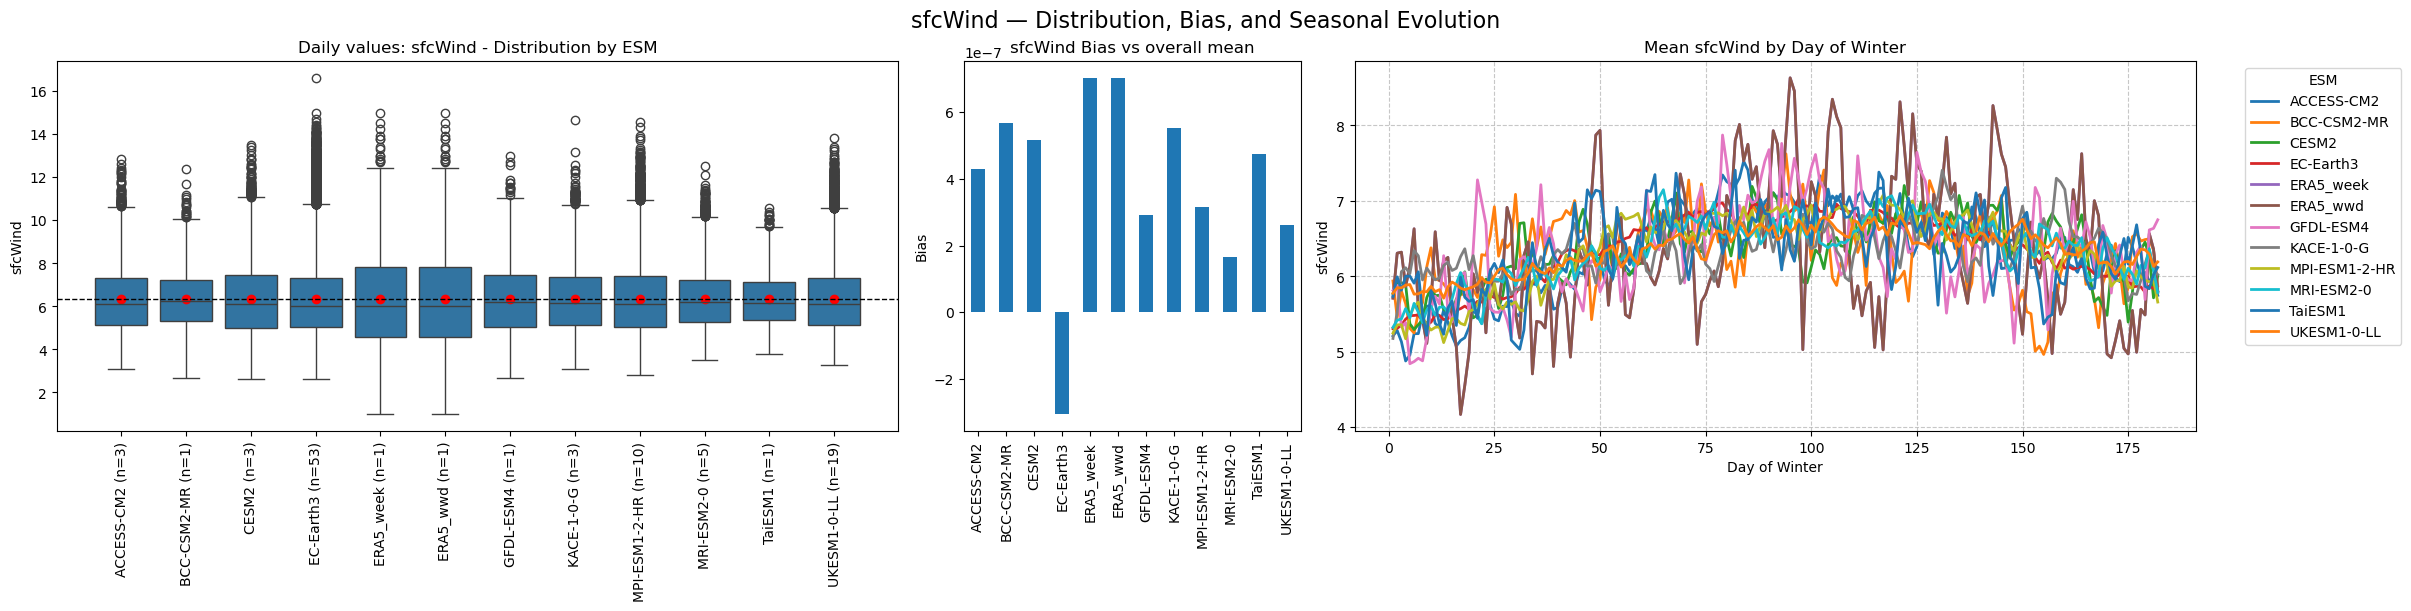

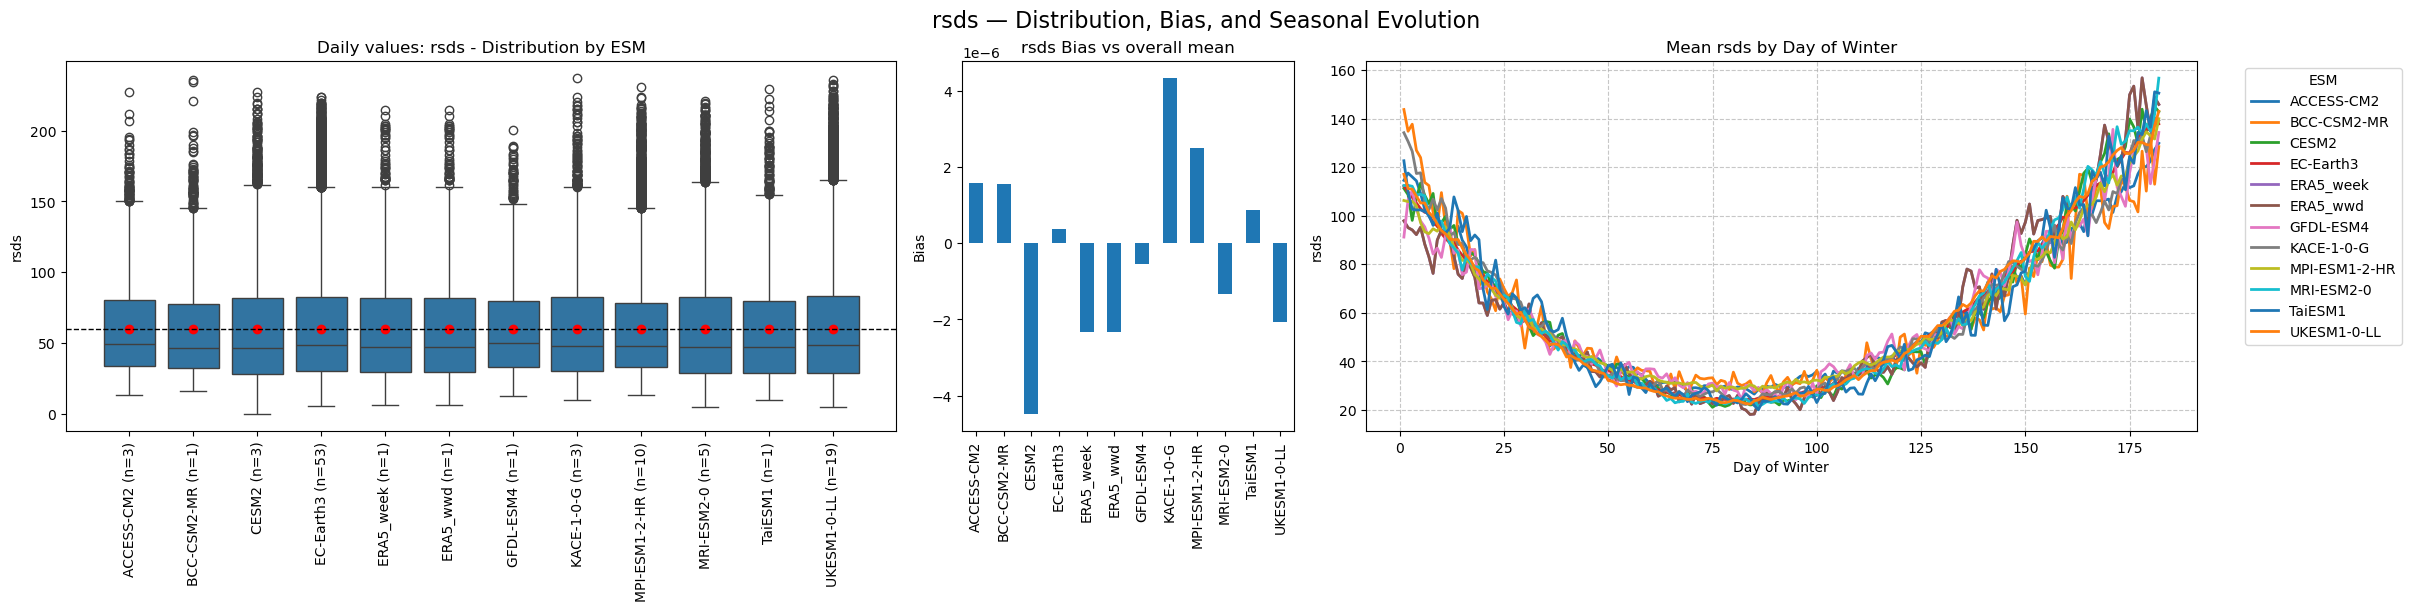

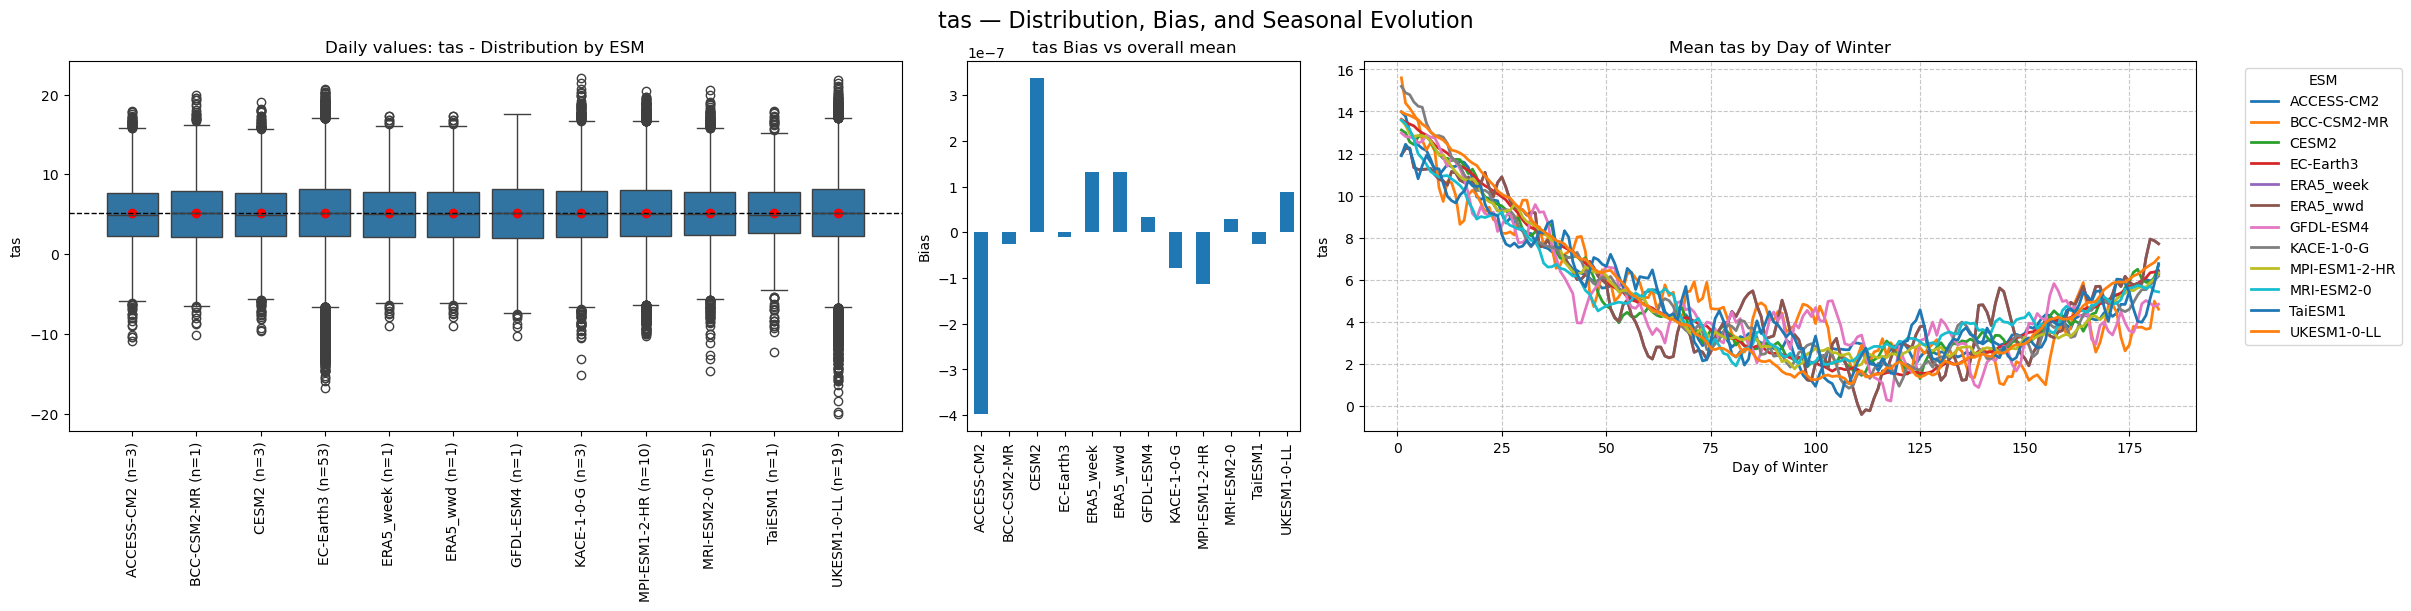

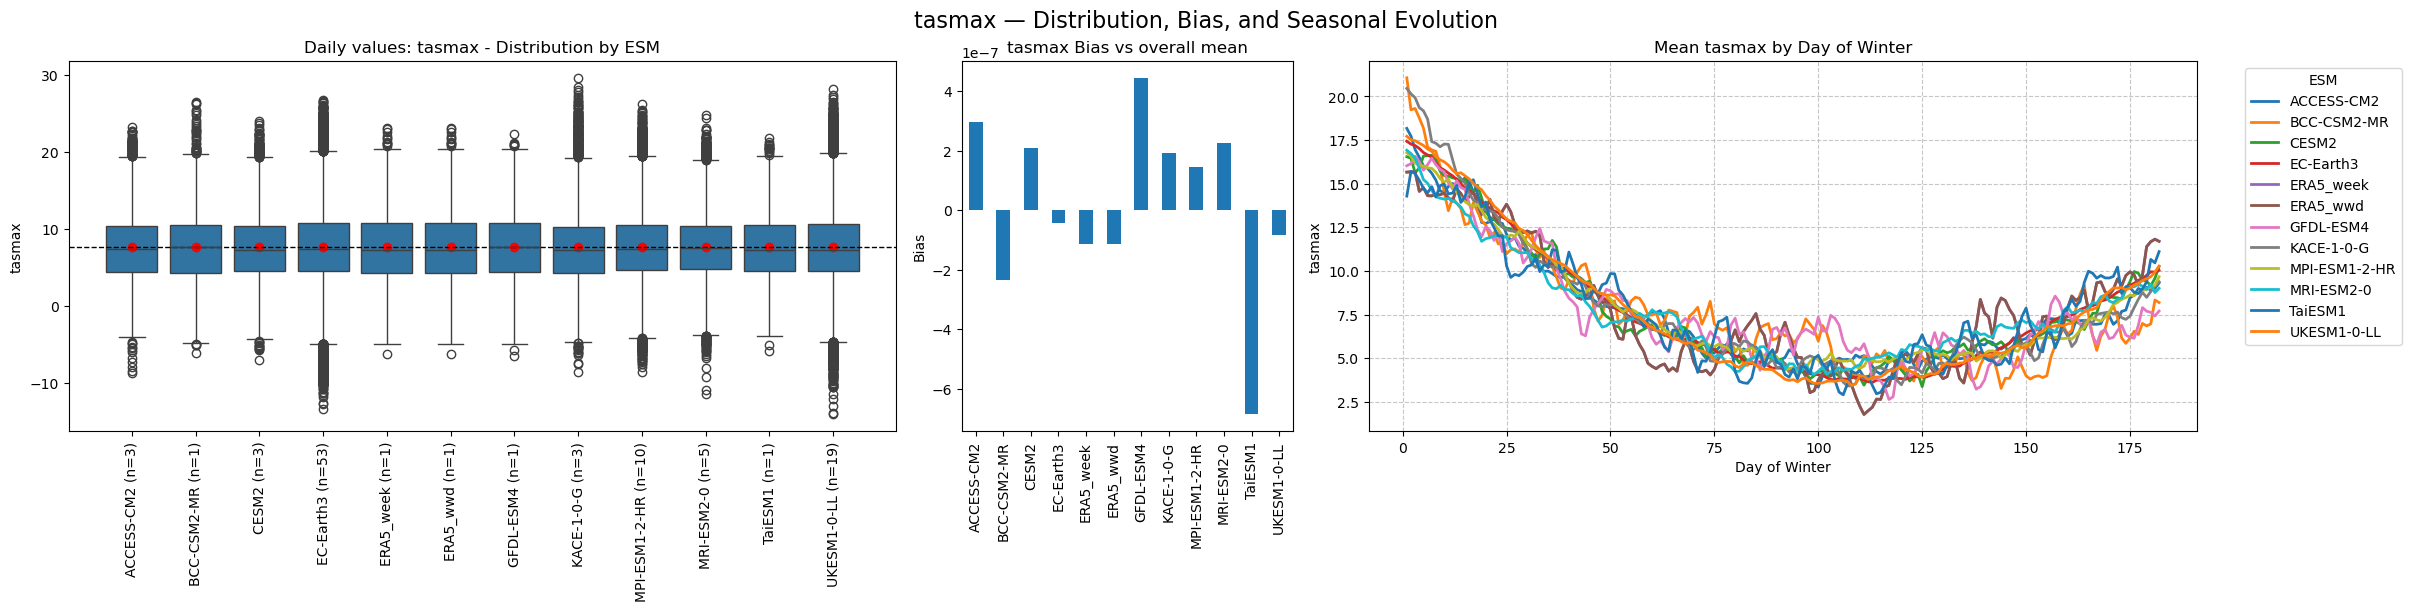

In [8]:

# Loop over variables and plot boxplot, bias, and seasonal lineplot
for var in variables:
    fig, axes = plt.subplots(
        1, 3,
        figsize=(24, 6),
        gridspec_kw={'width_ratios': [3, 1.2, 3]},
        constrained_layout=True
    )

    # 1. Boxplot (left)
    sns.boxplot(data=df, x='ESM_label', y=var, ax=axes[0])
    means = df.groupby('ESM_label')[var].mean()
    # Add mean as a line
    axes[0].plot(means.index, means.values, color='red', marker='o', linestyle='', label='Mean')
    axes[0].axhline(y=ts_datasets[var].mean('time').mean(), color='black', linestyle='--', linewidth=1)

    axes[0].set_title(f'Daily values: {var} - Distribution by ESM')
    axes[0].tick_params(axis='x', rotation=90)
    axes[0].set_xlabel('')
    axes[0].set_ylabel(var)

    # 2. Bias barplot (middle)

    model_mean = ts_datasets[var].groupby('ESM').mean().mean('time')
    overall_mean = ts_datasets[var].mean('time').mean()
    bias = model_mean - overall_mean

    bias.to_series().plot.bar(ax=axes[1])
    axes[1].set_title(f'{var} Bias vs overall mean')
    axes[1].set_ylabel('Bias')
    axes[1].set_xlabel('')
    axes[1].tick_params(axis='x', rotation=90)


    # 3. Line plot (right)

    if var in final_df.columns:
        for esm, group in final_df.groupby('ESM'):
            # if esm == 'ERA5_week':
            if esm == 'ERA5':
                axes[2].plot(group['day_of_winter'], group[var], color='red', linewidth=3, label='ERA5')
            # elif esm == 'ERA5_wwd':
            #     continue
            else:
                axes[2].plot(group['day_of_winter'], group[var], linewidth=2, label=esm)

        axes[2].set_title(f'Mean {var} by Day of Winter')
        axes[2].set_xlabel('Day of Winter')
        axes[2].set_ylabel(var)
        axes[2].grid(True, linestyle='--', alpha=0.7)
        axes[2].legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=10, title='ESM')
    else:
        axes[2].text(0.5, 0.5, f'{var} not in final_df', ha='center', va='center')
        axes[2].set_axis_off()


    # Title
    plt.suptitle(f'{var} — Distribution, Bias, and Seasonal Evolution', fontsize=16)
    plt.show()


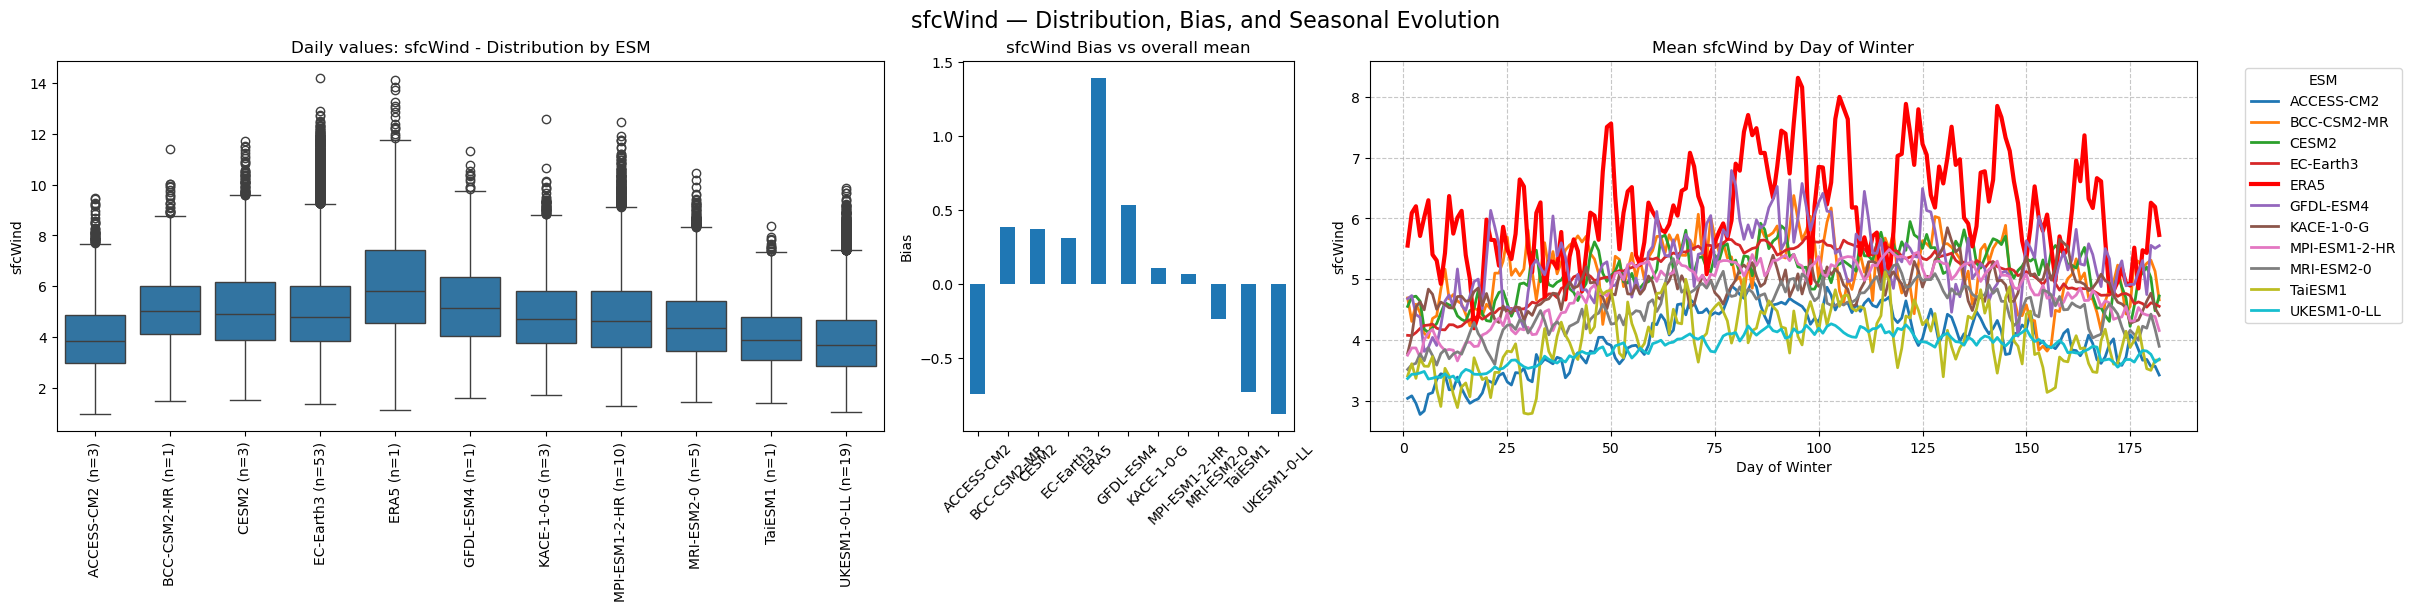

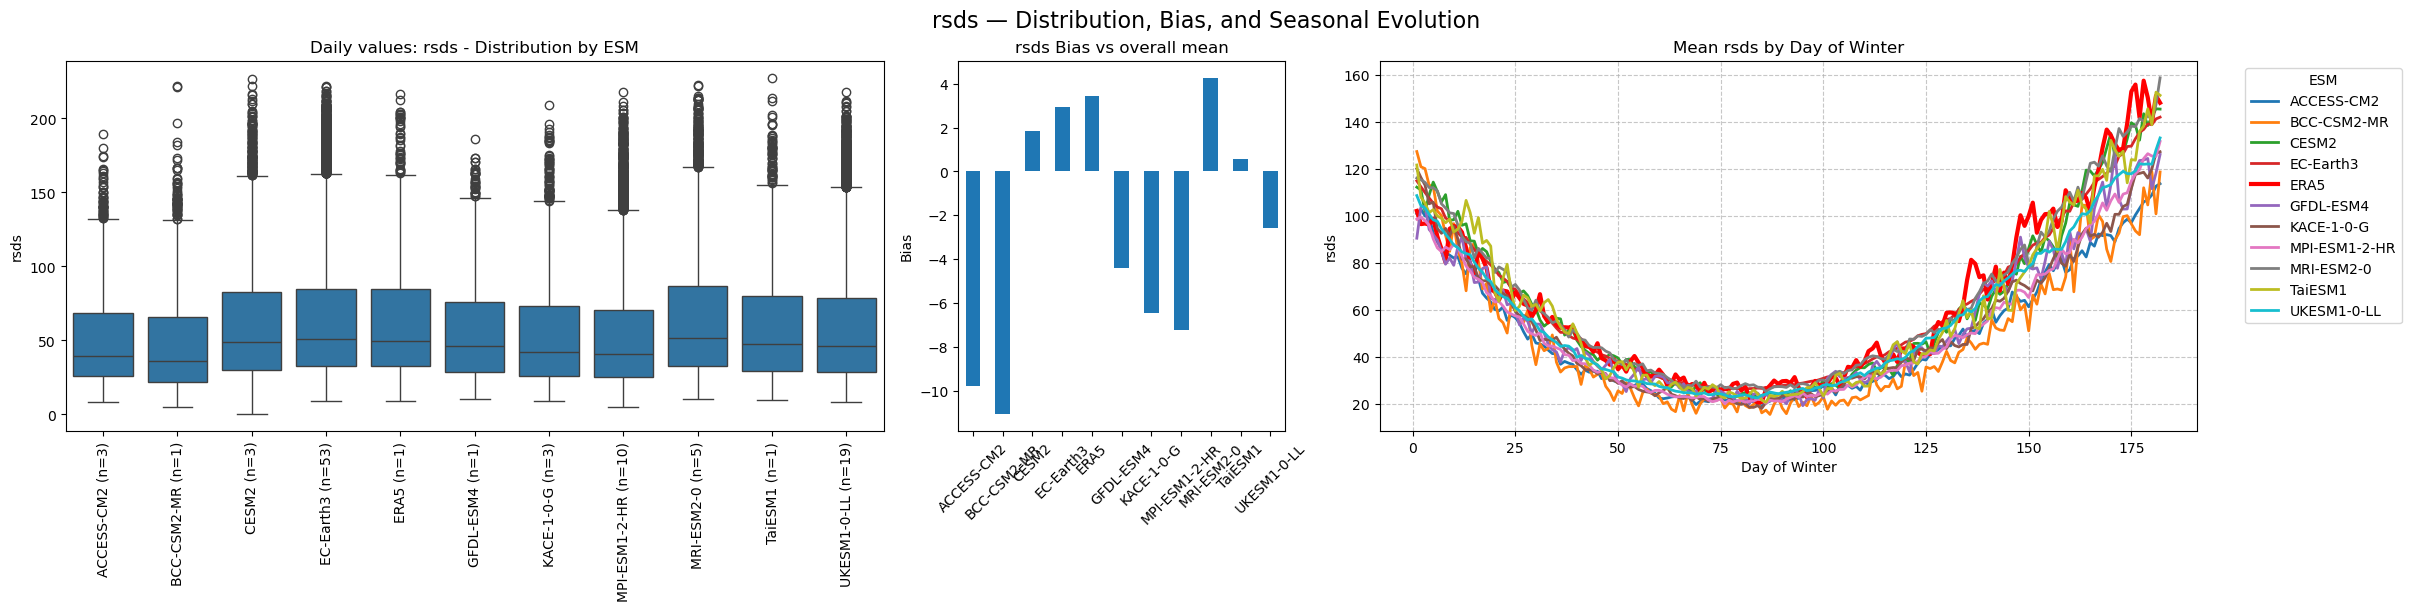

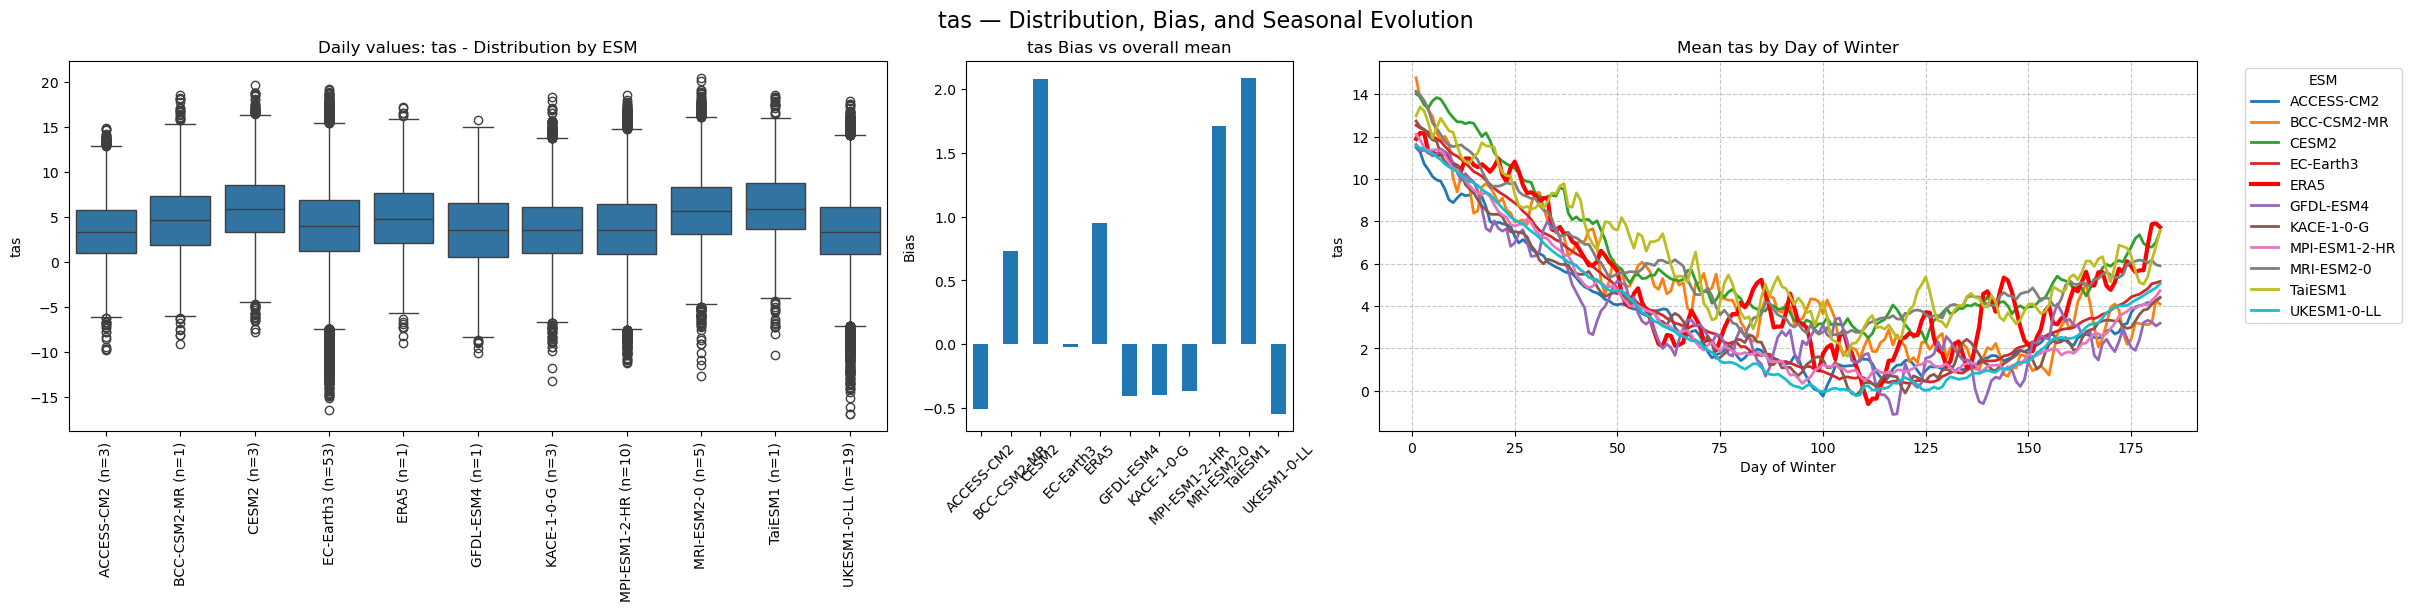

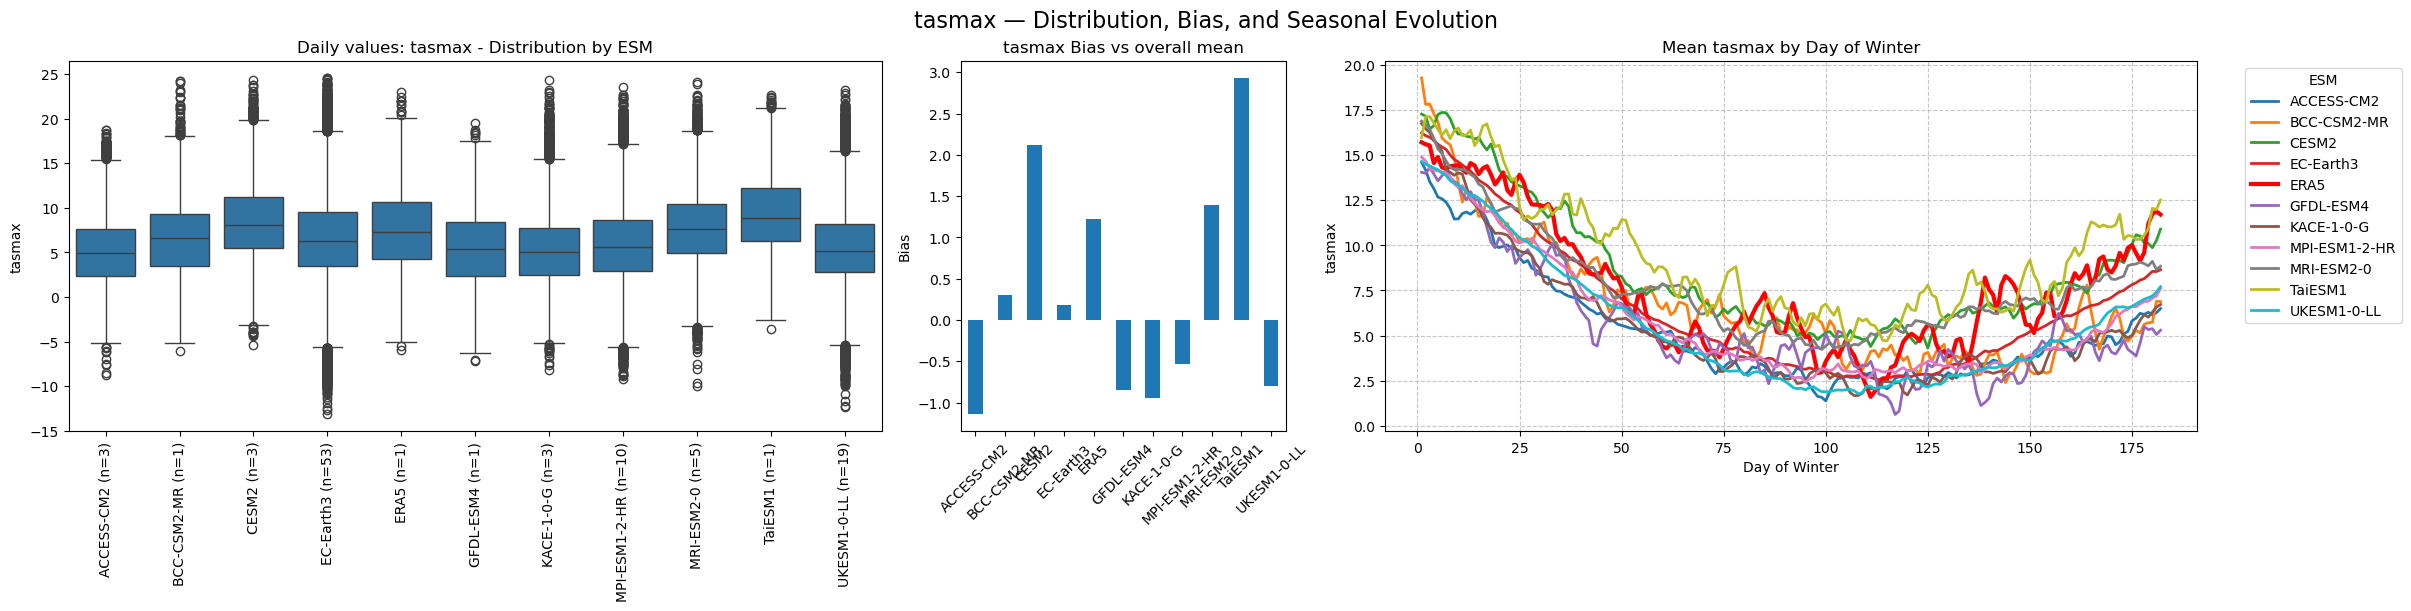

In [36]:

# Loop over variables and plot boxplot, bias, and seasonal lineplot
for var in variables:
    fig, axes = plt.subplots(
        1, 3,
        figsize=(24, 6),
        gridspec_kw={'width_ratios': [3, 1.2, 3]},
        constrained_layout=True
    )

    # 1. Boxplot (left)
    sns.boxplot(data=df, x='ESM_label', y=var, ax=axes[0])
    axes[0].set_title(f'Daily values: {var} - Distribution by ESM')
    axes[0].tick_params(axis='x', rotation=90)
    axes[0].set_xlabel('')
    axes[0].set_ylabel(var)

    # 2. Bias barplot (middle)

    model_mean = ts_datasets[var].groupby('ESM').mean().mean('time')
    overall_mean = ts_datasets[var].mean('time').mean()
    bias = model_mean - overall_mean

    bias.to_series().plot.bar(ax=axes[1])
    axes[1].set_title(f'{var} Bias vs overall mean')
    axes[1].set_ylabel('Bias')
    axes[1].set_xlabel('')
    axes[1].tick_params(axis='x', rotation=45)


    # 3. Line plot (right)

    if var in final_df.columns:
        for esm, group in final_df.groupby('ESM'):
            if esm == 'ERA5':
                axes[2].plot(group['day_of_winter'], group[var], color='red', linewidth=3, label='ERA5')
            else:
                axes[2].plot(group['day_of_winter'], group[var], linewidth=2, label=esm)

        axes[2].set_title(f'Mean {var} by Day of Winter')
        axes[2].set_xlabel('Day of Winter')
        axes[2].set_ylabel(var)
        axes[2].grid(True, linestyle='--', alpha=0.7)
        axes[2].legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=10, title='ESM')
    else:
        axes[2].text(0.5, 0.5, f'{var} not in final_df', ha='center', va='center')
        axes[2].set_axis_off()


    # Title
    plt.suptitle(f'{var} — Distribution, Bias, and Seasonal Evolution', fontsize=16)
    plt.show()


-----

#### Plots to look at masked mean values

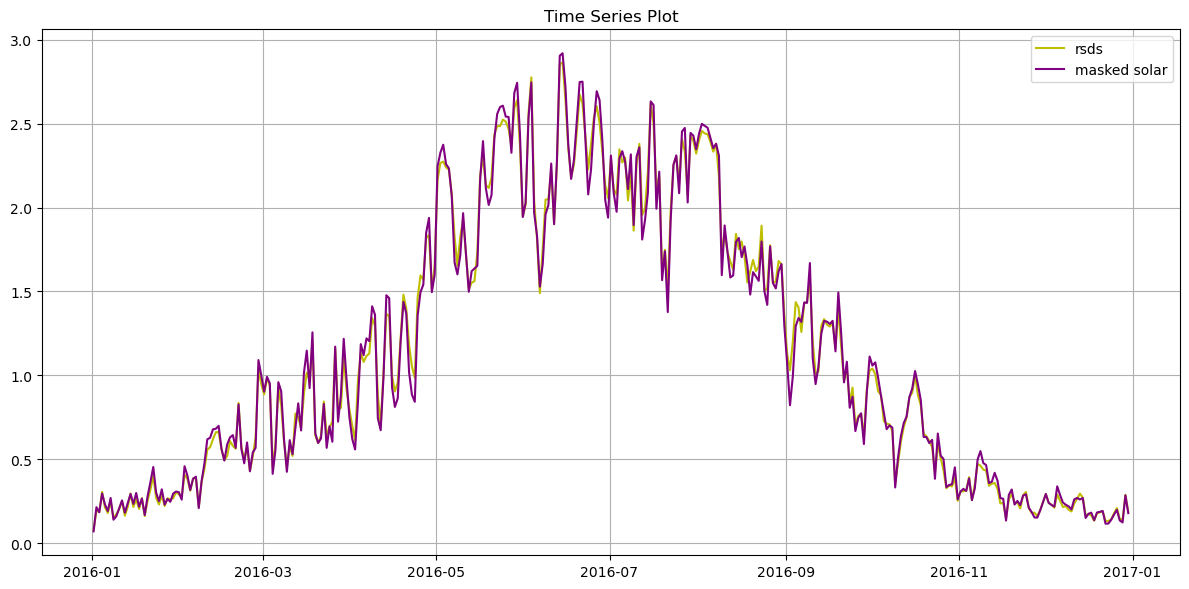

In [46]:
# Define your slice (adjust these to your desired time range)
# a = 0
# b = 364
a = 365
b = 365 * 2

# Extract time and variables for the chosen range
time = ts_output['time'][a:b]
rsds = ts_output['rsds'][a:b] / 110
solar = ts_output['solar'][a:b] / 66

# Create the figure and axis
fig, ax = plt.subplots(figsize=(12, 6))

# Plot each variable
ax.plot(time, rsds, label='rsds', color='y')
ax.plot(time, solar, label='masked solar', color='purple')

# Labeling
ax.set_xlabel('')
ax.set_ylabel('')
ax.set_title('Time Series Plot')
ax.legend()

# Formatting
fig.tight_layout()
plt.grid(True)
plt.show()

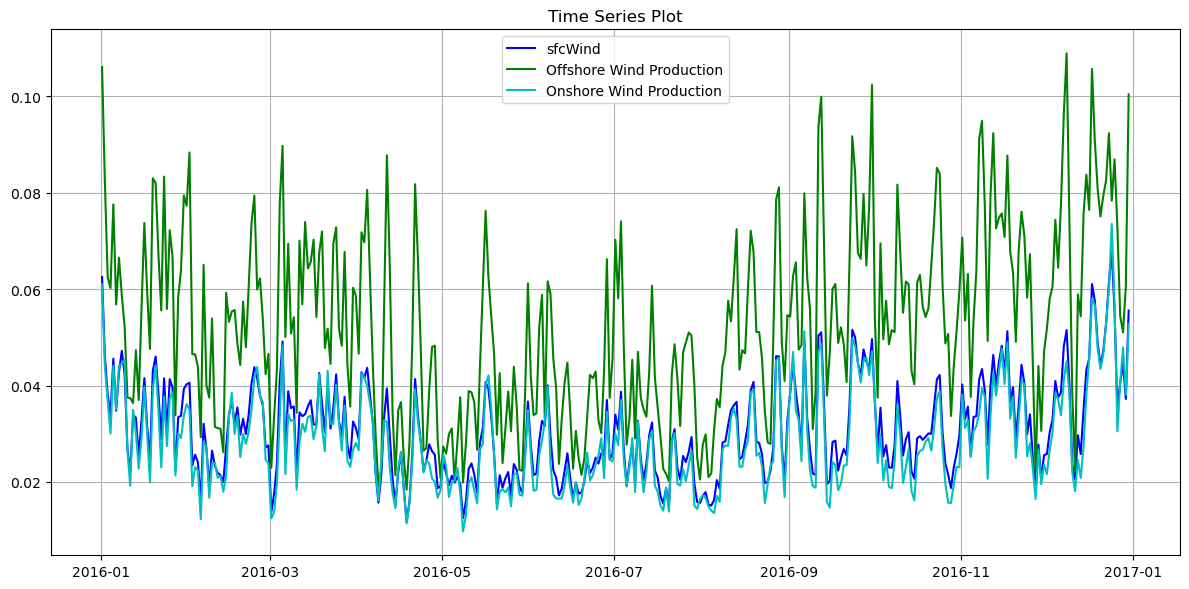

In [47]:
# Define your slice (adjust these to your desired time range)
# a = 0
# b = 364
a = 365
b = 365 * 2

# Extract time and variables for the chosen range
time = ts_output['time'][a:b]
sfcWind = ts_output['sfcWind'][a:b] / 110
wind_offshore = ts_output['wind_offshore'][a:b] / 9
wind_onshore = ts_output['wind_onshore'][a:b] / 63

# Create the figure and axis
fig, ax = plt.subplots(figsize=(12, 6))

# Plot each variable
ax.plot(time, sfcWind, label='sfcWind', color='b')
ax.plot(time, wind_offshore, label='Offshore Wind Production', color='g')
ax.plot(time, wind_onshore, label='Onshore Wind Production', color='c')

# Labeling
ax.set_xlabel('')
ax.set_ylabel('')
ax.set_title('Time Series Plot')
ax.legend()

# Formatting
fig.tight_layout()
plt.grid(True)
plt.show()